In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

- p≤0.001: ***
- p≤0.01: **
- p≤0.05: *

# Research Question 1
### Bir recsys’in fairnessını etkileyen faktörler (data ve model karakteristikleri) nelerdir ?

    1. Önce genel.girdi: fairness metrikler hariç her şey. target = fairness measureları (her measure için ayrı ayrı regression yapılacak)
    2. fairness metrik sayımız kadar model çalışacak. target değerimiz hep farklı fairness metrikleri olacak bu durumda her fairness metrik için farklı değerler önemli olabilir sonucuna varabiliriz

### Table 7

In [10]:
df = pd.read_excel("./fairness_measure_based/TEST_RQ1_OLS_Regression_Feature_Analysis_fairness_measure_based.xlsx")

df["Feature"].unique()

array(['Number of Items', 'Number of Ratings', 'Number of Users', 'hit@5',
       'Rating per User', 'Mean Rating', 'Gini User',
       'Standart Deviation of Rating', 'Density', 'Rating per Item',
       'Skewness of Long Tail Items',
       'Difference between Sensitive Attribute Percentage',
       'Skewness of Popularity Bias', 'Dataset_ml1m', 'Model Name_FOCF',
       'Model Name_PFCN_MLP', 'const', 'Sensitive Feature_Age',
       'Model Name_NFCF', 'Sensitive Feature_Gender', 'Dataset_BX',
       'Gini Item', 'Shape'], dtype=object)

In [11]:
import pandas as pd

df = pd.read_excel("./fairness_measure_based/TEST_RQ1_OLS_Regression_Feature_Analysis_fairness_measure_based.xlsx")

features = [
    "Rating per User",
    "Number of Ratings",
    "Mean Rating",
    "Number of Users",
    "Number of Items",
    "hit@5",
    "Gini User",
    "Difference between Sensitive Attribute Percentage"
]

metric_order = [
    "Differential Fairness",
    "Generalized Cross Entropy",
    "KS Statistic",
    "Overestimation Unfairness",
    "Value Unfairness"
]

# Gerekli kolonları al
df2 = df[["Feature", "Target Measure", "Coefficient"]].copy()

# SADECE istediğin feature'ları filtrele
df2 = df2[df2["Feature"].isin(features)]

# Pivot
pivot_df = df2.pivot(
    index="Feature",
    columns="Target Measure",
    values="Coefficient"
)

# Feature sırası (makale sırası)
pivot_df = pivot_df.reindex(features)

# Metric sırası
pivot_df = pivot_df[metric_order]

# Metric isimlerini kısalt
rename_map = {
    "Differential Fairness": "DF",
    "Generalized Cross Entropy": "GCE",
    "KS-Statistics": "KS",
    "Overestimation Unfairness": "OU",
    "Value Unfairness": "VU"
}

pivot_df = pivot_df.rename(columns=rename_map)

# Daha okunabilir
pivot_df = pivot_df.round(3)

pivot_df

Target Measure,DF,GCE,KS Statistic,OU,VU
Feature,,,,,
Rating per User,0.735,-0.832,-0.810,1.614,0.617
Number of Ratings,-2.016,1.278,1.199,-1.734,-3.818
Mean Rating,1.963,3.654,-2.175,3.728,2.995
Number of Users,0.936,-0.753,-0.286,1.557,1.247
Number of Items,2.154,-0.938,-0.186,0.815,2.702
hit@5,0.981,-0.064,0.801,0.364,-0.435
Gini User,0.773,-0.233,-0.428,1.265,0.555
Difference between Sensitive Attribute Percentage,0.776,-4.516,0.944,-0.244,0.382


In [2]:
# TABLE 7
df_all = pd.read_excel("./fairness_measure_based/RQ1_OLS_Regression_Feature_Analysis_fairness_measure_based.xlsx")

df_all["Is Important"] = df_all["Significance"].notna()
total_target_measures = df_all["Target Measure"].nunique()

importance_analysis = df_all.groupby("Feature").agg(
    Total_Target_Measures=("Target Measure", "nunique"),
    Important_Target_Measures=("Is Important", "sum"),
    Importance_Percentage=("Is Important", lambda x: x.sum() / total_target_measures * 100),
).reset_index()

importance_analysis = importance_analysis.sort_values(by="Importance_Percentage", ascending=False)
importance_analysis

KeyError: 'Significance'

In [188]:
df_all = pd.read_excel("./fairness_measure_based/TEST_RQ1_OLS_Regression_Feature_Analysis_fairness_measure_based.xlsx")
df= df_all[df_all["Significance (raw)"].notna()]
df = df[['Feature',  'P-Value (raw)', 'P-Value (Bonferroni)', 'Significance (raw)',
       'Significance (bonf)' ,"Target Measure"]]

In [189]:
df

,Feature,P-Value (raw),P-Value (Bonferroni),Significance (raw),Significance (bonf),Target Measure
0,Number of Items,1.643182e-23,3.615001e-22,***,***,Value Unfairness
1,Number of Ratings,1.173176e-16,2.580988e-15,***,***,Value Unfairness
2,Number of Users,4.936015e-05,1.085923e-03,***,**,Value Unfairness
3,hit@5,2.527150e-04,5.559731e-03,***,**,Value Unfairness
4,Rating per User,5.169803e-04,1.137357e-02,***,*,Value Unfairness
5,Mean Rating,3.026227e-03,6.657698e-02,**,NaN,Value Unfairness
6,Gini User,3.474988e-02,7.644974e-01,*,NaN,Value Unfairness
23,Rating per User,2.067498e-33,4.548495e-32,***,***,Overestimation Unfairness
24,Number of Users,4.372354e-12,9.619179e-11,***,***,Overestimation Unfairness
25,Gini User,5.483853e-11,1.206448e-09,***,***,Overestimation Unfairness


In [194]:
import pandas as pd
import numpy as np

# 1) Yeni fonksiyonun ürettiği dosyayı oku
# Örn: ./fairness_measure_based/RQ1_AllMeasures_OLS_Results_bonferroni_RQ1.xlsx
df_all = pd.read_excel("./fairness_measure_based/RQ1_AllMeasures_OLS_Results_bonferroni_RQ1.xlsx")

# 2) İstediğin kolonları seç (const'u da istersen at)
df = df_all[[
    "Feature",
    "Target Measure",
    "P-Value (raw)",
    "P-Value (corrected)",
    "Significance (raw)",
    "Significance (corrected)",
]].copy()

# İstersen const'u çıkar (önerilir)
df = df[df["Feature"] != "const"].copy()

# 3) Significance flag’lerini EN SAĞLAM şekilde p-value’dan üret
# (stars kolonları NaN/"" tutarsızlık yaratmasın)
df["Sig_raw"] = df["P-Value (raw)"].astype(float) <= 0.05
df["Sig_corr"] = df["P-Value (corrected)"].astype(float) <= 0.05

# --------------------------------------------------------
# 1️⃣ TARGET MEASURE bazında kaç feature significant?
# --------------------------------------------------------
summary_target = (
    df.groupby("Target Measure")
      .agg(
          Total_Features=("Feature", "nunique"),
          Significant_raw=("Sig_raw", "sum"),
          Significant_corrected=("Sig_corr", "sum"),
      )
      .reset_index()
)

summary_target["Lost_after_correction"] = (
    summary_target["Significant_raw"] - summary_target["Significant_corrected"]
)

summary_target["Retention_Rate"] = np.where(
    summary_target["Significant_raw"] > 0,
    summary_target["Significant_corrected"] / summary_target["Significant_raw"],
    np.nan
)

print("\n=== TARGET MEASURE LEVEL SUMMARY ===")
print(summary_target.sort_values("Retention_Rate", ascending=True))


# --------------------------------------------------------
# 2️⃣ FEATURE bazında kaç target measure’da significant?
# --------------------------------------------------------
summary_feature = (
    df.groupby("Feature")
      .agg(
          Total_Target_Measures=("Target Measure", "nunique"),
          Significant_raw=("Sig_raw", "sum"),
          Significant_corrected=("Sig_corr", "sum"),
      )
      .reset_index()
)

summary_feature["Lost_after_correction"] = (
    summary_feature["Significant_raw"] - summary_feature["Significant_corrected"]
)

summary_feature["Retention_Rate"] = np.where(
    summary_feature["Significant_raw"] > 0,
    summary_feature["Significant_corrected"] / summary_feature["Significant_raw"],
    np.nan
)

summary_feature = summary_feature.sort_values(
    by=["Significant_raw", "Lost_after_correction"],
    ascending=[False, False]
)

print("\n=== FEATURE LEVEL SUMMARY ===")
print(summary_feature)


# --------------------------------------------------------
# 3️⃣ Hangi feature hangi target measure’da significance kaybetti?
# --------------------------------------------------------
lost_significance = df[(df["Sig_raw"] == True) & (df["Sig_corr"] == False)].copy()
lost_significance = lost_significance.sort_values(["Target Measure", "Feature"])

print("\n=== SIGNIFICANCE LOST AFTER CORRECTION ===")
print(lost_significance[[
    "Feature", "Target Measure",
    "P-Value (raw)", "P-Value (corrected)"
]])


# --------------------------------------------------------
# 4️⃣ Pivot: correction sonrası significance matrisi
# --------------------------------------------------------
pivot_corrected = df.pivot_table(
    index="Feature",
    columns="Target Measure",
    values="Sig_corr",
    aggfunc="sum",
    fill_value=0
)

print("\n=== CORRECTED SIGNIFICANCE MATRIX (1 means significant) ===")
print(pivot_corrected)


# --------------------------------------------------------
# 5️⃣ Stability classification
# --------------------------------------------------------
df["Stability"] = np.where(
    (df["Sig_raw"] == True) & (df["Sig_corr"] == True),
    "Stable",
    np.where(
        (df["Sig_raw"] == True) & (df["Sig_corr"] == False),
        "Lost after correction",
        "Not significant"
    )
)

stability_summary = df.groupby("Feature")["Stability"].value_counts().unstack(fill_value=0)

print("\n=== STABILITY SUMMARY PER FEATURE ===")
print(stability_summary)


# --------------------------------------------------------
# 6) İstersen hepsini excel'e kaydet
# --------------------------------------------------------
summary_target.to_excel("./fairness_measure_based/RQ1_Summary_Target_raw_vs_corrected.xlsx", index=False)
summary_feature.to_excel("./fairness_measure_based/RQ1_Summary_Feature_raw_vs_corrected.xlsx", index=False)
lost_significance.to_excel("./fairness_measure_based/RQ1_Lost_Significance_raw_to_corrected.xlsx", index=False)


=== TARGET MEASURE LEVEL SUMMARY ===
                                     Target Measure  Total_Features  \
2               KS Statistic of sensitive attribute              22   
0      Differential Fairness of sensitive attribute              22   
1                         Generalized Cross Entropy              22   
4           Value Unfairness of sensitive attribute              22   
3  Overestimation Unfairness of sensitive attribute              22   

   Significant_raw  Significant_corrected  Lost_after_correction  \
2                5                      1                      4   
0               10                      5                      5   
1                8                      4                      4   
4                7                      4                      3   
3                8                      7                      1   

   Retention_Rate  
2        0.200000  
0        0.500000  
1        0.500000  
4        0.571429  
3        0.875000  

=== F

In [197]:
import pandas as pd
import numpy as np

# =========================
# 1) Dosyayı oku (yeni fonksiyon çıktısı)
# =========================
# Bonferroni yaptıysan bu dosya adı buna benzer:
# "./fairness_measure_based/RQ1_AllMeasures_OLS_Results_bonferroni_RQ1.xlsx"
# FDR yaptıysan: "..._fdr_bh_RQ1.xlsx"
df_all = pd.read_excel("./fairness_measure_based/RQ1_AllMeasures_OLS_Results_bonferroni_RQ1.xlsx")

# const'u çıkar
df_all = df_all[df_all["Feature"] != "const"].copy()

# =========================
# 2) Target Measure -> Kod (DF, GCE, KS, OU, VU)
# =========================
tm_map = {
    "Differential Fairness of sensitive attribute": "DF",
    "Generalized Cross Entropy": "GCE",
    "KS Statistic of sensitive attribute": "KS",
    "Overestimation Unfairness of sensitive attribute": "OU",
    "Value Unfairness of sensitive attribute": "VU",
}

# Hangi target measure'lar var görelim (map dışı varsa hata verelim)
unknown = set(df_all["Target Measure"].unique()) - set(tm_map.keys())
if unknown:
    raise ValueError(f"Target Measure mapping eksik. Şunlar map'te yok: {unknown}")

df_all["TM_Code"] = df_all["Target Measure"].map(tm_map)

# Kod sırası (tabloda bu sırayla yazdıracağız)
tm_order = ["DF", "GCE", "KS", "OU", "VU"]

# =========================
# 3) Significance flag'leri (p-value'dan)
# =========================
# Raw p-value
df_all["Sig_raw"] = df_all["P-Value (raw)"].astype(float) <= 0.05

# Corrected p-value (global bonf/fdr sonucunun yazıldığı kolon)
# Senin son fonksiyonda adı: "P-Value (corrected)"
if "P-Value (corrected)" not in df_all.columns:
    raise ValueError("Beklenen kolon yok: 'P-Value (corrected)'. Dosya yanlış olabilir.")

df_all["Sig_corr"] = df_all["P-Value (corrected)"].astype(float) <= 0.05

# =========================
# 4) Feature isimlerini paper’daki sembollere çevirmek istersen (opsiyonel)
# =========================
# Burayı kendi paper’ındaki notation’a göre güncelle.
feature_symbol_map = {
    "Rating per User": r"$R_{u}$",
    "Number of Ratings": r"$|R|$",
    "Mean Rating": r"$\mu_R$",
    "Number of Users": r"$|U|$",
    "Number of Items": r"$|I|$",
    "hit@5": r"$HR@5$",
    "Gini User": r"$Gini_{u}$",
    "Difference between Sensitive Attribute Percentage": r"$\Delta S_{perc}$",
    "Shape": r"$Shape$",
    "Gini Item": r"$Gini_{item}$",
    "Rating per Item": r"$R_{i}$",
    "Std Rating": r"$\sigma_R$",
    "Sparsity": r"$\rho$",
}

df_all["Feature_Display"] = df_all["Feature"].map(feature_symbol_map).fillna(df_all["Feature"])

# =========================
# 5) Aggregation: her feature için listeler ve oranlar
# =========================
def metrics_list(subdf, flag_col):
    codes = subdf.loc[subdf[flag_col], "TM_Code"].tolist()
    # sıralı ve unique
    codes = [c for c in tm_order if c in set(codes)]
    return ", ".join(codes) if codes else "--"

agg = (
    df_all.groupby(["Feature", "Feature_Display"])
    .apply(lambda g: pd.Series({
        "Raw_Count": int(g["Sig_raw"].sum()),
        "Raw_Metrics": metrics_list(g, "Sig_raw"),
        "Corr_Count": int(g["Sig_corr"].sum()),
        "Corr_Metrics": metrics_list(g, "Sig_corr"),
    }))
    .reset_index()
)

total_measures = len(tm_order)  # 5

agg["Raw_Sig"] = agg["Raw_Count"].astype(str) + f"/{total_measures}"
agg["Corr_Sig"] = agg["Corr_Count"].astype(str) + f"/{total_measures}"

# Eski tablonun sıralamasına benzer: Raw_Count desc
agg = agg.sort_values(by=["Raw_Count", "Corr_Count"], ascending=[False, False]).reset_index(drop=True)

# =========================
# 6) Final tablo (LaTeX)
# =========================
final_table = agg[[
    "Feature_Display",
    "Raw_Sig",
    "Raw_Metrics",
    "Corr_Sig",
    "Corr_Metrics",
]].rename(columns={
    "Feature_Display": "Feature",
    "Raw_Sig": "Ratio of Significance",
    "Raw_Metrics": "Significant Metrics (Raw)",
    "Corr_Sig": "Ratio of Significance (Corrected)",
    "Corr_Metrics": "Significant Metrics (Corrected)",
})

print(final_table)

latex = final_table.to_latex(
    index=False,
    escape=False,      # LaTeX math ($...$) bozulmasın
    column_format="lcccc",
)

print("\n\n=== LaTeX TABLE ===\n")
print(latex)

                         Feature Ratio of Significance  \
0                        $R_{u}$                   5/5   
1                          $|I|$                   4/5   
2                         $HR@5$                   4/5   
3                          $|R|$                   4/5   
4                        $\mu_R$                   4/5   
5                          $|U|$                   4/5   
6                     $Gini_{u}$                   3/5   
7              $\Delta S_{perc}$                   2/5   
8                        $Shape$                   2/5   
9                  $Gini_{item}$                   2/5   
10                       $R_{i}$                   2/5   
11                       Density                   1/5   
12  Standart Deviation of Rating                   1/5   
13                    Dataset_BX                   0/5   
14                  Dataset_ml1m                   0/5   
15               Model Name_FOCF                   0/5   
16            

### Table 8
* Regression Coefficients

In [32]:
importance_feature_list = list(importance_analysis[importance_analysis.Important_Target_Measures>0].Feature)
print(df_all[df_all.Feature.isin(importance_feature_list)][["Feature", "Target Measure","Coefficient"]])

             Feature    Target Measure  Coefficient
2        Mean Rating  Value Unfairness     0.159506
3    Number of Items  Value Unfairness     0.143896
4    Number of Users  Value Unfairness     0.066392
5    Rating per User  Value Unfairness     0.032853
6          Gini User  Value Unfairness     0.029572
..               ...               ...          ...
104        Gini User      KS Statistic    -0.018415
105  Rating per User      KS Statistic    -0.034846
106        Gini Item      KS Statistic    -0.065248
107  Rating per Item      KS Statistic    -0.066175
108      Mean Rating      KS Statistic    -0.093516

[65 rows x 3 columns]


In [131]:
import os
# COHEN F^2 VE PARTIAL R^2
base_dir = "./fairness_measure_based/"

files = {
    "Value Unfairness": "OLS_Regression_Feature_Analysis_Value_Unfairness_of_sensitive_attribute.xlsx",
    "Overestimation Unfairness": "OLS_Regression_Feature_Analysis_Overestimation_Unfairness_of_sensitive_attribute.xlsx",
    "Differential Fairness": "OLS_Regression_Feature_Analysis_Differential_Fairness_of_sensitive_attribute.xlsx",
    "Generalized Cross Entropy": "OLS_Regression_Feature_Analysis_Generalized_Cross_Entropy.xlsx",
    "KS Statistic": "OLS_Regression_Feature_Analysis_KS_Statistic_of_sensitive_attribute.xlsx",
}


dfs = {}
for measure, fname in files.items():
    fpath = os.path.join(base_dir, fname)
    dfs[measure] = pd.read_excel(fpath)
    

df_all = pd.concat(
    [df.assign(Measure=measure) for measure, df in dfs.items()],
    ignore_index=True
)


In [133]:
# --- Categorization functions ---
def categorize_partial_r2(x):
    if pd.isna(x):
        return np.nan
    if x < 0.01:
        return "Negligible"
    elif x < 0.05:
        return "Small"
    elif x < 0.10:
        return "Medium"
    else:
        return "Large"   # (>= 0.10) -> strong/large

def categorize_cohen_f2(x):
    if pd.isna(x):
        return np.nan
    if x < 0.02:
        return "Negligible"
    elif x < 0.15:
        return "Small"
    elif x < 0.35:
        return "Medium"
    else:
        return "Large"


df_all["effect_size_partial_r2"] = df_all["Partial_R2"].apply(categorize_partial_r2)
df_all["effect_size_cohen_f2"]   = df_all["Cohen_f2"].apply(categorize_cohen_f2)


order = ["Negligible", "Small", "Medium", "Large"]
df_all["effect_size_partial_r2"] = pd.Categorical(df_all["effect_size_partial_r2"], categories=order, ordered=True)
df_all["effect_size_cohen_f2"]   = pd.Categorical(df_all["effect_size_cohen_f2"], categories=order, ordered=True)

df_all[["Measure", "Feature", "Partial_R2", "effect_size_partial_r2", "Cohen_f2", "effect_size_cohen_f2"]].head()

,Measure,Feature,Partial_R2,effect_size_partial_r2,Cohen_f2,effect_size_cohen_f2
0,Value Unfairness,Number of Items,0.107323,Large,0.386799,Large
1,Value Unfairness,Number of Ratings,0.075092,Medium,0.270634,Medium
2,Value Unfairness,Number of Users,0.018555,Small,0.066874,Small
3,Value Unfairness,hit@5,0.015111,Small,0.054462,Small
4,Value Unfairness,Rating per User,0.013611,Small,0.049056,Small


In [137]:
import pandas as pd
import numpy as np

# ============================================================
# 0) Effect size categorization helpers
# ============================================================
def categorize_partial_r2(x):
    # Partial R^2 thresholds:
    # <0.01 negligible, 0.01-0.05 small, 0.05-0.10 medium, >=0.10 large
    if pd.isna(x):
        return np.nan
    if x < 0.01:
        return "Negligible"
    elif x < 0.05:
        return "Small"
    elif x < 0.10:
        return "Medium"
    else:
        return "Large"

def categorize_cohen_f2(x):
    # Cohen's f^2 thresholds:
    # <0.02 negligible, 0.02-0.15 small, 0.15-0.35 medium, >=0.35 large
    if pd.isna(x):
        return np.nan
    if x < 0.02:
        return "Negligible"
    elif x < 0.15:
        return "Small"
    elif x < 0.35:
        return "Medium"
    else:
        return "Large"

# ============================================================
# 1) Your significance summary table -> df_sig
# ============================================================
rows = [
    {"Feature":"Rating per User","Sig_Count":5,"Total_Target_Measures":5,"Ratio_of_Significance":"5/5"},
    {"Feature":"Mean Rating","Sig_Count":4,"Total_Target_Measures":5,"Ratio_of_Significance":"4/5"},
    {"Feature":"Number of Items","Sig_Count":4,"Total_Target_Measures":5,"Ratio_of_Significance":"4/5"},
    {"Feature":"Number of Ratings","Sig_Count":4,"Total_Target_Measures":5,"Ratio_of_Significance":"4/5"},
    {"Feature":"Number of Users","Sig_Count":4,"Total_Target_Measures":5,"Ratio_of_Significance":"4/5"},
    {"Feature":"hit@5","Sig_Count":4,"Total_Target_Measures":5,"Ratio_of_Significance":"4/5"},
    {"Feature":"Gini Item","Sig_Count":3,"Total_Target_Measures":5,"Ratio_of_Significance":"3/5"},
    {"Feature":"Gini User","Sig_Count":3,"Total_Target_Measures":5,"Ratio_of_Significance":"3/5"},
    {"Feature":"Difference between Sensitive Attribute Percentage","Sig_Count":2,"Total_Target_Measures":5,"Ratio_of_Significance":"2/5"},
    {"Feature":"Model Name_FOCF","Sig_Count":2,"Total_Target_Measures":5,"Ratio_of_Significance":"2/5"},
    {"Feature":"Model Name_PFCN_MLP","Sig_Count":2,"Total_Target_Measures":5,"Ratio_of_Significance":"2/5"},
    {"Feature":"Rating per Item","Sig_Count":2,"Total_Target_Measures":5,"Ratio_of_Significance":"2/5"},
    {"Feature":"Shape","Sig_Count":2,"Total_Target_Measures":5,"Ratio_of_Significance":"2/5"},
    {"Feature":"Dataset_ml1m","Sig_Count":1,"Total_Target_Measures":5,"Ratio_of_Significance":"1/5"},
    {"Feature":"Density","Sig_Count":1,"Total_Target_Measures":5,"Ratio_of_Significance":"1/5"},
    {"Feature":"Model Name_NFCF","Sig_Count":1,"Total_Target_Measures":5,"Ratio_of_Significance":"1/5"},
    {"Feature":"Sensitive Feature_Gender","Sig_Count":1,"Total_Target_Measures":5,"Ratio_of_Significance":"1/5"},
    {"Feature":"Standart Deviation of Rating","Sig_Count":1,"Total_Target_Measures":5,"Ratio_of_Significance":"1/5"},
    {"Feature":"Dataset_BX","Sig_Count":0,"Total_Target_Measures":5,"Ratio_of_Significance":"0/5"},
    {"Feature":"Sensitive Feature_Age","Sig_Count":0,"Total_Target_Measures":5,"Ratio_of_Significance":"0/5"},
    {"Feature":"Skewness of Long Tail Items","Sig_Count":0,"Total_Target_Measures":5,"Ratio_of_Significance":"0/5"},
    {"Feature":"Skewness of Popularity Bias","Sig_Count":0,"Total_Target_Measures":5,"Ratio_of_Significance":"0/5"},
]
df_sig = pd.DataFrame(rows)

# Optional: normalize feature names to reduce merge mismatches
df_sig["Feature"] = df_sig["Feature"].astype(str).str.strip()

# ============================================================
# 2) Define which fairness measures to enrich from df_all
#    IMPORTANT: keys must match df_all["Measure"] values exactly
# ============================================================
fairness_measures = {
    "Value Unfairness": "Value_Unfairness",
    "Overestimation Unfairness": "Overestimation_Unfairness",
    "Differential Fairness": "Differential_Fairness",
    "Generalized Cross Entropy": "Generalized_Cross_Entropy",
    "KS Statistic": "KS_Statistic",
}

# Optional: normalize feature names in df_all too
# (Assumes df_all exists and has columns: Measure, Feature, Partial_R2, Cohen_f2)
df_all = df_all.copy()
df_all["Feature"] = df_all["Feature"].astype(str).str.strip()

# ============================================================
# 3) Enrich df_sig with Partial R^2 + categories and Cohen's f^2 + categories for each measure
# ============================================================
df_sig_enriched = df_sig.copy()

for measure_name, prefix in fairness_measures.items():
    df_m = df_all[df_all["Measure"].eq(measure_name)].copy()

    if df_m.empty:
        print(f" Measure not found in df_all['Measure']: {measure_name}")
        # still continue, leaving NaNs for that measure
        continue

    # Create categories (if you already have them, it's still fine to overwrite)
    df_m["effect_size_partial_r2"] = df_m["Partial_R2"].apply(categorize_partial_r2)
    df_m["effect_size_cohen_f2"]   = df_m["Cohen_f2"].apply(categorize_cohen_f2)

    # Keep necessary columns and rename with measure prefix
    df_m_small = df_m[[
        "Feature",
        "Partial_R2",
        "effect_size_partial_r2",
        "Cohen_f2",
        "effect_size_cohen_f2"
    ]].rename(columns={
        "Partial_R2": f"{prefix}_Partial_R2",
        "effect_size_partial_r2": f"{prefix}_Partial_R2_Category",
        "Cohen_f2": f"{prefix}_Cohens_F2",
        "effect_size_cohen_f2": f"{prefix}_Cohens_F2_Category",
    })

    # Merge by Feature
    df_sig_enriched = df_sig_enriched.merge(df_m_small, on="Feature", how="left")

# ============================================================
# 4) Save
# ============================================================
out_csv = "effect_size_all_fairness_measures.csv"
df_sig_enriched.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print(df_sig_enriched.head())


Saved: effect_size_all_fairness_measures.csv
             Feature  Sig_Count  Total_Target_Measures Ratio_of_Significance  \
0    Rating per User          5                      5                   5/5   
1        Mean Rating          4                      5                   4/5   
2    Number of Items          4                      5                   4/5   
3  Number of Ratings          4                      5                   4/5   
4    Number of Users          4                      5                   4/5   

   Value_Unfairness_Partial_R2 Value_Unfairness_Partial_R2_Category  \
0                     0.013611                                Small   
1                     0.009946                           Negligible   
2                     0.107323                                Large   
3                     0.075092                               Medium   
4                     0.018555                                Small   

   Value_Unfairness_Cohens_F2 Value_Unfairness_

In [139]:
df_sig_enriched

,Feature,Sig_Count,Total_Target_Measures,Ratio_of_Significance,Value_Unfairness_Partial_R2,Value_Unfairness_Partial_R2_Category,Value_Unfairness_Cohens_F2,Value_Unfairness_Cohens_F2_Category,Overestimation_Unfairness_Partial_R2,Overestimation_Unfairness_Partial_R2_Category,...,Differential_Fairness_Cohens_F2,Differential_Fairness_Cohens_F2_Category,Generalized_Cross_Entropy_Partial_R2,Generalized_Cross_Entropy_Partial_R2_Category,Generalized_Cross_Entropy_Cohens_F2,Generalized_Cross_Entropy_Cohens_F2_Category,KS_Statistic_Partial_R2,KS_Statistic_Partial_R2_Category,KS_Statistic_Cohens_F2,KS_Statistic_Cohens_F2_Category
0,Rating per User,5,5,5/5,0.013611,Small,0.049056,Small,0.152065,Large,...,0.094886,Small,0.030544,Small,0.138198,Small,0.010485,Small,0.016809,Negligible
1,Mean Rating,4,5,4/5,0.009946,Negligible,0.035847,Small,0.028711,Small,...,0.021289,Small,0.018423,Small,0.083356,Small,0.002351,Negligible,0.003770,Negligible
2,Number of Items,4,5,4/5,0.107323,Large,0.386799,Large,0.020341,Small,...,0.347714,Medium,0.017874,Small,0.080874,Small,0.000253,Negligible,0.000405,Negligible
3,Number of Ratings,4,5,4/5,0.075092,Medium,0.270634,Medium,0.030826,Small,...,0.109407,Small,0.011299,Small,0.051124,Small,0.003549,Negligible,0.005690,Negligible
4,Number of Users,4,5,4/5,0.018555,Small,0.066874,Small,0.053060,Medium,...,0.052222,Small,0.008587,Negligible,0.038851,Small,0.000444,Negligible,0.000711,Negligible
5,hit@5,4,5,4/5,0.015111,Small,0.054462,Small,0.020008,Small,...,0.354506,Large,0.000417,Negligible,0.001885,Negligible,0.022613,Small,0.036251,Small
6,Gini Item,3,5,3/5,0.000093,Negligible,0.000334,Negligible,0.003169,Negligible,...,0.020289,Small,0.004293,Negligible,0.019423,Negligible,0.007369,Negligible,0.011813,Negligible
7,Gini User,3,5,3/5,0.005055,Negligible,0.018220,Negligible,0.047712,Small,...,0.048343,Small,0.001125,Negligible,0.005089,Negligible,0.001343,Negligible,0.002153,Negligible
8,Difference between Sensitive Attribute Percentage,2,5,2/5,0.001076,Negligible,0.003878,Negligible,0.000833,Negligible,...,0.021989,Small,0.159156,Large,0.720115,Large,0.002924,Negligible,0.004687,Negligible
9,Model Name_FOCF,2,5,2/5,0.000822,Negligible,0.002962,Negligible,0.001056,Negligible,...,0.010085,Negligible,0.000477,Negligible,0.002159,Negligible,0.003036,Negligible,0.004867,Negligible


# Research Question 2
### How does the choice of dataset and RS model affect the observed characteristics reported in RQ1?
target = fairness, input: model fixed and all features
1.2 target = fairness, input: dataset and sensitive attribute fixed and all features


### Table 9

In [24]:
# TABLE 7
df_focf = pd.read_excel("./fairness_measure_based_RQ2/RQ2_OLS_Regression_Feature_Analysis_fairness_measure_based_FOCF.xlsx")
df_focf["Model"]="FOCF"
df_nfcf = pd.read_excel("./fairness_measure_based_RQ2/RQ2_OLS_Regression_Feature_Analysis_fairness_measure_based_NFCF.xlsx")
df_nfcf["Model"]="NFCF"
df_pfcn = pd.read_excel("./fairness_measure_based_RQ2/RQ2_OLS_Regression_Feature_Analysis_fairness_measure_based_PFCN_MLP.xlsx")
df_pfcn["Model"]="PFCN"

df_all = pd.concat([df_focf, df_nfcf, df_pfcn])


In [26]:
df_all["Is Important"] = df_all["Significance"].notna()
total_target_measures = df_all["Target Measure"].nunique()

importance_analysis = df_all.groupby(["Feature", "Model"]).agg(
    Total_Target_Measures=("Target Measure", "nunique"),
    Important_Target_Measures=("Is Important", "sum"),
    Importance_Percentage=("Is Important", lambda x: x.sum() / total_target_measures * 100),
).reset_index()

pivot_df = (
    importance_analysis
    .pivot(index="Feature", columns="Model", values="Important_Target_Measures")
    .fillna(0)
    .astype(int)
)


In [28]:
order = (
    pivot_df.assign(_sum=pivot_df.sum(axis=1), _max=pivot_df.max(axis=1))
            .sort_values(by=["_sum", "_max"], ascending=False)
            .index
)
pivot_df = pivot_df.loc[order]

In [30]:
pivot_df[["NFCF","FOCF","PFCN"]]

Model,NFCF,FOCF,PFCN
Feature,,,
Rating per User,4,4,5
Dataset_BX,4,3,3
Mean Rating,3,3,4
Number of Items,4,2,4
Sensitive Feature_Age,3,3,4
const,3,3,4
Sensitive Feature_Gender,3,2,4
Number of Ratings,3,3,3
Number of Users,2,3,3


### Table 10

In [39]:
# TABLE 10
df_ml1m_age = pd.read_excel("./fairness_measure_based_RQ2/RQ2_OLS_Regression_Feature_Analysis_fairness_measure_based_ML1M_Age.xlsx")
df_ml1m_age["Dataset-Sensitive Attribute"]="ML1M-Age"
df_ml1m_gender = pd.read_excel("./fairness_measure_based_RQ2/RQ2_OLS_Regression_Feature_Analysis_fairness_measure_based_ML1M_Gender.xlsx")
df_ml1m_gender["Dataset-Sensitive Attribute"]="ML1M-Gender"
df_bx_age = pd.read_excel("./fairness_measure_based_RQ2/RQ2_OLS_Regression_Feature_Analysis_fairness_measure_based_BX_Age.xlsx")
df_bx_age["Dataset-Sensitive Attribute"]="BX-Age"

df_all = pd.concat([df_ml1m_age, df_ml1m_gender, df_bx_age])


In [40]:
df_all["Is Important"] = df_all["Significance"].notna()
total_target_measures = df_all["Target Measure"].nunique()

importance_analysis = df_all.groupby(["Feature", "Dataset-Sensitive Attribute"]).agg(
    Total_Target_Measures=("Target Measure", "nunique"),
    Important_Target_Measures=("Is Important", "sum"),
    Importance_Percentage=("Is Important", lambda x: x.sum() / total_target_measures * 100),
).reset_index()

pivot_df = (
    importance_analysis
    .pivot(index="Feature", columns="Dataset-Sensitive Attribute", values="Important_Target_Measures")
    .fillna(0)
    .astype(int)
)


In [41]:
order = (
    pivot_df.assign(_sum=pivot_df.sum(axis=1), _max=pivot_df.max(axis=1))
            .sort_values(by=["_sum", "_max"], ascending=False)
            .index
)
pivot_df = pivot_df.loc[order]

In [42]:
pivot_df[["ML1M-Age","ML1M-Gender","BX-Age"]]

Dataset-Sensitive Attribute,ML1M-Age,ML1M-Gender,BX-Age
Feature,,,
Model Name_NFCF,4,5,4
const,4,5,2
Model Name_FOCF,3,4,4
Number of Ratings,3,5,2
Model Name_PFCN_MLP,3,4,3
Difference between Sensitive Attribute Percentage,3,4,1
Gini User,1,2,4
hit@5,2,2,3
Density,1,3,1


# Research Question 4
### How do the influential data and model characteristics for fairness change when the goal is optimizing the accuracy of fair RSs?


## Table 12

In [53]:
# TABLE 12
df_all = pd.read_excel("./accuracy_metric_based/RQ4_OLS_Regression_Feature_Analysis_accuracy_metric_based.xlsx")

df_all["Is Important"] = df_all["Significance"].notna()
total_target_measures = df_all["Target Measure"].nunique()

importance_analysis = df_all.groupby("Feature").agg(
    Total_Target_Measures=("Target Measure", "nunique"),
    Important_Target_Measures=("Is Important", "sum"),
    Importance_Percentage=("Is Important", lambda x: x.sum() / total_target_measures * 100),
).reset_index()

importance_analysis = importance_analysis.sort_values(by="Importance_Percentage", ascending=False)

In [54]:
importance_analysis[importance_analysis["Importance_Percentage"]>0]

,Feature,Total_Target_Measures,Important_Target_Measures,Importance_Percentage
2,Density,1,1,100.0
25,Value Unfairness of sensitive attribute,1,1,100.0
4,Differential Fairness of sensitive attribute,1,1,100.0
6,Gini Item,1,1,100.0
7,Gini User,1,1,100.0
8,KS Statistic of sensitive attribute,1,1,100.0
17,Rating per Item,1,1,100.0


## Table 13

In [59]:
# TABLE 7
df_focf = pd.read_excel("./accuracy_metric_based_RQ2/RQ4_OLS_Regression_Feature_Analysis_accuracy_metric_based_FOCF.xlsx")
df_focf["Model"]="FOCF"
df_nfcf = pd.read_excel("./accuracy_metric_based_RQ2/RQ4_OLS_Regression_Feature_Analysis_accuracy_metric_based_NFCF.xlsx")
df_nfcf["Model"]="NFCF"
df_pfcn = pd.read_excel("./accuracy_metric_based_RQ2/RQ4_OLS_Regression_Feature_Analysis_accuracy_metric_based_PFCN_MLP.xlsx")
df_pfcn["Model"]="PFCN"

df_all = pd.concat([df_focf, df_nfcf, df_pfcn])


In [60]:
df_all["Is Important"] = df_all["Significance"].notna()
total_target_measures = df_all["Target Measure"].nunique()

importance_analysis = df_all.groupby(["Feature", "Model"]).agg(
    Total_Target_Measures=("Target Measure", "nunique"),
    Important_Target_Measures=("Is Important", "sum"),
    Importance_Percentage=("Is Important", lambda x: x.sum() / total_target_measures * 100),
).reset_index()

pivot_df = (
    importance_analysis
    .pivot(index="Feature", columns="Model", values="Important_Target_Measures")
    .fillna(0)
    .astype(int)
)


In [61]:
order = (
    pivot_df.assign(_sum=pivot_df.sum(axis=1), _max=pivot_df.max(axis=1))
            .sort_values(by=["_sum", "_max"], ascending=False)
            .index
)
pivot_df = pivot_df.loc[order]

In [63]:
pivot_df[["NFCF","FOCF","PFCN"]]


Model,NFCF,FOCF,PFCN
Feature,,,
Gini Item,1,1,1
Gini User,1,1,0
KS Statistic of sensitive attribute,1,0,1
Overestimation Unfairness of sensitive attribute,0,1,1
Rating per Item,1,0,1
Skewness of Popularity Bias,1,1,0
Dataset_ml1m,1,0,0
Difference between Sensitive Attribute Percentage,1,0,0
Differential Fairness of sensitive attribute,0,1,0


# Research Question 3
### What interaction effects between data characteristics and RS models shape fairness outcomes, and can these interactions reveal patterns not observable from individual characteristics alone?


## Table 11

In [ ]:
# Table 11: sadece fairness target: interaction termler dahil.

In [3]:
# TABLE 7
import pandas as pd
df_all = pd.read_excel("./fairness_measure_based/RQ3_OLS_Regression_Feature_Analysis_fairness_measure_based_interaction.xlsx")

df_all["Is Important"] = df_all["Significance"].notna()
total_target_measures = df_all["Target Measure"].nunique()

importance_analysis = df_all.groupby("Feature").agg(
    Total_Target_Measures=("Target Measure", "nunique"),
    Important_Target_Measures=("Is Important", "sum"),
    Importance_Percentage=("Is Important", lambda x: x.sum() / total_target_measures * 100),
).reset_index()

importance_analysis = importance_analysis.sort_values(by="Importance_Percentage", ascending=False)
importance_analysis[importance_analysis.Feature.str.contains("Model")]

,Feature,Total_Target_Measures,Important_Target_Measures,Importance_Percentage
59,Mean Rating Model Name_FOCF,5,4,80.0
48,Gini User Model Name_NFCF,5,3,60.0
47,Gini User Model Name_FOCF,5,3,60.0
60,Mean Rating Model Name_NFCF,5,3,60.0
61,Mean Rating Model Name_PFCN_MLP,5,3,60.0
...,...,...,...,...
167,Rating per User Model Name_PFCN_MLP,5,0,0.0
166,Rating per User Model Name_NFCF,5,0,0.0
165,Rating per User Model Name_FOCF,5,0,0.0
112,Number of Ratings Model Name_NFCF,5,0,0.0


In [5]:
#models = ["Model Name_PFCN_MLP", "Model Name_NFCF", "Model Name_FOCF"]
models = ["Model Name_NFCF"]

sig_rows = df_all[
    df_all["Feature"].str.contains("|".join(models), case=False, na=False) &
    df_all["Feature"].str.contains("|".join(["Mean Rating"]), case=False, na=False) &
    (df_all["Significance"].notna())
]
sig_rows

,Feature,Coefficient,P-Value,Significance,Target Measure,Is Important
225,Mean Rating Model Name_NFCF,-1.449127,0.004716,**,Value Unfairness,True
470,Mean Rating Model Name_NFCF,-2.072611,0.002051,**,Overestimation Unfairness,True
1235,Mean Rating Model Name_NFCF,-1.846616,0.016319,*,KS Statistic,True


In [175]:
import pandas as pd

# KOLON ADLARI
COL_FEATURE = "Feature"
COL_TARGET  = "Target Measure"   # sende böyleyse

# Target Measure -> kısaltma (senin kullandıkların)
abbr_map = {
    "Value Unfairness": "VU",
    "Overestimation Unfairness": "OU",
    "Underestimation Unfairness": "UU",
    "Absolute Unfairness": "AU",
    "NonParity Unfairness": "NP",
    "Differential Fairness": "DF",
    "KS Statistic": "KS",
    "Generalized Cross Entropy": "GCE",
}

# Uzun isimlerde (…of sensitive attribute) içeriyorsa da yakala
def to_abbr(x: str) -> str:
    x = str(x)
    if x in abbr_map:
        return abbr_map[x]
    for k, v in abbr_map.items():
        if k in x:
            return v
    return x  # eşleşmezse olduğu gibi

metric_order = ["VU", "OU", "DF", "KS", "GCE", "UU", "AU", "NP"]

def join_sorted_unique(vals):
    uniq = sorted(set(vals), key=lambda m: metric_order.index(m) if m in metric_order else 999)
    return ", ".join(uniq)

# SADECE 2 KOLONU KULLAN
tmp = sig_rows[[COL_FEATURE, COL_TARGET]].copy()
tmp["metric_abbr"] = tmp[COL_TARGET].apply(to_abbr)

result_table = (
    tmp.groupby(COL_FEATURE)["metric_abbr"]
       .apply(join_sorted_unique)
       .reset_index()
       .rename(columns={
           COL_FEATURE: "Feature",
           "metric_abbr": "# of Significant Metrics"
       })
)

# İstersen kaç metrik var (sayısal) diye ayrı kolon da ekleyelim:
result_table["count"] = result_table["# of Significant Metrics"].str.count(",") + 1

# Çoktan aza sırala
result_table = result_table.sort_values("count", ascending=False).drop(columns=["count"]).reset_index(drop=True)

result_table


,Feature,# of Significant Metrics
0,Mean Rating Model Name_FOCF,"VU, OU, DF, KS"
1,Mean Rating Model Name_PFCN_MLP,"VU, OU, KS"
2,Mean Rating Model Name_NFCF,"VU, OU, KS"
3,Gini User Model Name_FOCF,"VU, KS, GCE"
4,Gini User Model Name_NFCF,"VU, KS, GCE"
5,Rating per Item Model Name_PFCN_MLP,"OU, KS"
6,Density Model Name_NFCF,"OU, GCE"
7,Rating per Item Model Name_FOCF,"OU, KS"
8,Model Name_FOCF Sensitive Feature_Gender,"DF, KS"
9,Rating per Item Model Name_NFCF,"OU, KS"


In [151]:
df_df = pd.read_excel("./fairness_measure_based/OLS_Regression_Feature_Analysis_Overestimation_Unfairness_of_sensitive_attribute_interaction.xlsx")
df_df[df_df.Significance.notna()]

,Feature,Coefficient,P-Value,Significance
0,Number of Ratings,261.937646,0.049449,*
1,Number of Ratings Dataset_BX,158.886597,0.048908,*
2,Number of Ratings Sensitive Feature_Age,158.503211,0.049280,*
3,Number of Ratings Sensitive Feature_Gender,125.227084,0.049596,*
5,Number of Ratings Model Name_FOCF,85.970429,0.049109,*
...,...,...,...,...
268,Density Standart Deviation of Rating,-13.367241,0.000080,***
269,Rating per Item Mean Rating,-13.695688,0.000892,***
271,Mean Rating,-33.664777,0.024924,*
272,Shape Rating per User,-35.349427,0.044476,*


In [152]:
df = importance_analysis[importance_analysis["Important_Target_Measures"]>0].copy()
models = ["Model Name_FOCF", "Model Name_NFCF", "Model Name_PFCN_MLP"]

# sadece bu modelleri filtrele
df_sub = df[df["Feature"].str.contains("|".join(models), na=False)].copy()

# model ve base feature ayır
df_sub["Model"] = df_sub["Feature"].str.extract(r'(Model Name_[A-Z_]+)')
df_sub["Base_Feature"] = df_sub["Feature"].str.replace(r'Model Name_[A-Z_]+', '', regex=True).str.strip()

# her model kaç unique feature ile kombinasyonlanmış
result = (
    df_sub.groupby("Model")["Base_Feature"]
    .nunique()
    .reset_index(name="unique_feature_count")
)

In [154]:
df_sub

,Feature,Total_Target_Measures,Important_Target_Measures,Importance_Percentage,Model,Base_Feature
53,Gini User Model Name_NFCF,5,2,40.0,Model Name_NFCF,Gini User
52,Gini User Model Name_FOCF,5,2,40.0,Model Name_FOCF,Gini User
222,Skewness of Long Tail Items Model Name_FOCF,5,2,40.0,Model Name_FOCF,Skewness of Long Tail Items
223,Skewness of Long Tail Items Model Name_NFCF,5,2,40.0,Model Name_NFCF,Skewness of Long Tail Items
224,Skewness of Long Tail Items Model Name_PFCN_MLP,5,2,40.0,Model Name_PFCN_MLP,Skewness of Long Tail Items
54,Gini User Model Name_PFCN_MLP,5,2,40.0,Model Name_PFCN_MLP,Gini User
14,Density Model Name_PFCN_MLP,5,2,40.0,Model Name_PFCN_MLP,Density
13,Density Model Name_NFCF,5,2,40.0,Model Name_NFCF,Density
12,Density Model Name_FOCF,5,2,40.0,Model Name_FOCF,Density
26,Difference between Sensitive Attribute Percent...,5,2,40.0,Model Name_FOCF,Difference between Sensitive Attribute Percentage


## RANDOM FOREST

In [146]:
df_df = pd.read_excel("./fairness_measure_based/RF_Feature_Importance_Differential_Fairness_of_sensitive_attribute.xlsx")
df_gce = pd.read_excel(
    "./fairness_measure_based/RF_Feature_Importance_Generalized_Cross_Entropy.xlsx")
df_ks = pd.read_excel(
    "./fairness_measure_based/RF_Feature_Importance_KS_Statistic_of_sensitive_attribute.xlsx")
df_ou = pd.read_excel(
    "./fairness_measure_based/RF_Feature_Importance_Overestimation_Unfairness_of_sensitive_attribute.xlsx")
df_vu = pd.read_excel(
    "./fairness_measure_based/RF_Feature_Importance_Value_Unfairness_of_sensitive_attribute.xlsx")

In [147]:
all_files = [df_df, df_gce, df_ks, df_ou, df_vu]  # tüm fairness metric dosyaların
metric_names = [
    "Differential_Fairness",
    "Generalized_Cross_Entropy",
    "KS_Statistic_of_sensitive_attribute",
    "Overestimation_Unfairness",
    "Value_Unfairness"
]
df_all = pd.concat(all_files, keys=metric_names, names=["metric"])

mean_imp = (
    df_all.groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
)

print(mean_imp.head(10))

Feature
Model Name_FOCF                                      0.188758
hit@5                                                0.165465
Difference between Sensitive Attribute Percentage    0.159944
Shape                                                0.055688
Rating per Item                                      0.054180
Number of Items                                      0.045187
Number of Users                                      0.039942
Rating per User                                      0.038387
Gini Item                                            0.037477
Number of Ratings                                    0.036405
Name: Importance, dtype: float64


In [148]:
df_df, df_gce, df_ks, df_ou, df_vu

(                                              Feature  Importance
 0                                     Model Name_FOCF    0.286775
 1                                     Rating per Item    0.177553
 2                                               Shape    0.156059
 3                                           Gini Item    0.123718
 4                                     Number of Items    0.078857
 5                                               hit@5    0.038414
 6                        Standart Deviation of Rating    0.025740
 7                                             Density    0.023500
 8   Difference between Sensitive Attribute Percentage    0.020005
 9                                           Gini User    0.015615
 10                                        Mean Rating    0.011824
 11                                  Number of Ratings    0.010337
 12                                    Number of Users    0.005770
 13                        Skewness of Popularity Bias    0.00

In [149]:
df_gce

,Feature,Importance
0,Difference between Sensitive Attribute Percentage,0.703807
1,Skewness of Popularity Bias,0.050069
2,Standart Deviation of Rating,0.043440
3,Number of Items,0.027586
4,Rating per User,0.026563
5,Gini Item,0.021880
6,Mean Rating,0.019534
7,Number of Ratings,0.018896
8,Skewness of Long Tail Items,0.018060
9,Shape,0.015128


In [118]:
df_vu.sort_values(by="Importance", ascending=False).head(5)

,Feature,Importance
0,hit@5,0.403872
1,Sensitive Feature_Gender,0.157727
2,Number of Ratings,0.103124
3,Shape,0.052446
4,Number of Items,0.045869


In [106]:
imp_stats = (
    df_all.groupby("Feature")["Importance"]
    .agg(mean="mean", std="std", max='max')
)

# hem yüksek mean hem düşük cv
robust = imp_stats.sort_values(["mean", "std"], ascending=[False, True])
robust.head(15)

,mean,std,max
Feature,,,
Model Name_FOCF,0.188758,0.269353,0.620900
hit@5,0.165465,0.190402,0.403872
Difference between Sensitive Attribute Percentage,0.159944,0.304813,0.703807
Shape,0.055688,0.057730,0.156059
Rating per Item,0.054180,0.070840,0.177553
Number of Items,0.045187,0.020727,0.078857
Number of Users,0.039942,0.067238,0.160027
Rating per User,0.038387,0.049450,0.125582
Gini Item,0.037477,0.048492,0.123718


In [107]:
robust.shape

(22, 3)

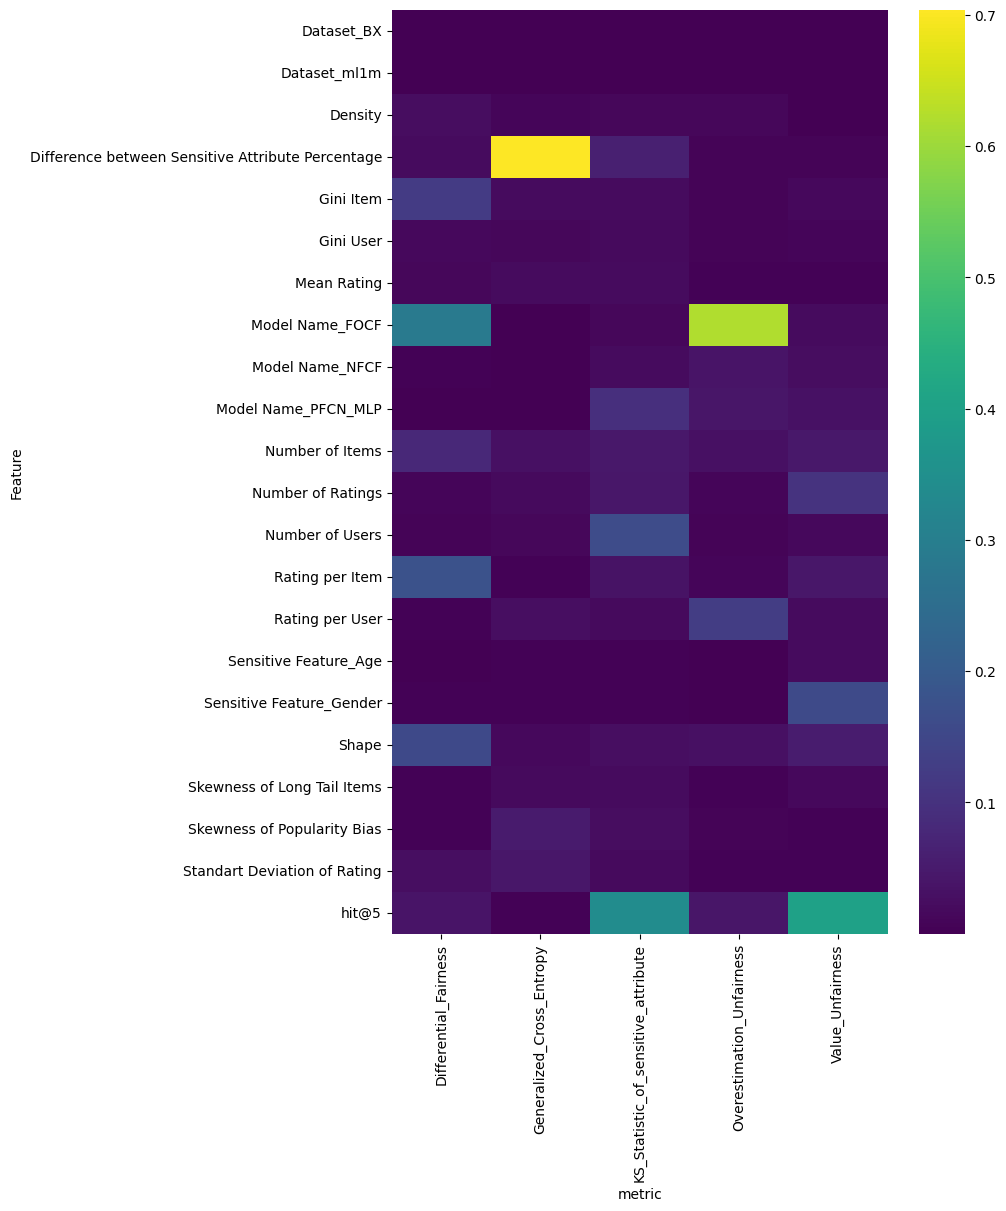

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_all.reset_index().pivot_table(
    index="Feature",
    columns="metric",
    values="Importance"
)

plt.figure(figsize=(8,12))
sns.heatmap(pivot, cmap="viridis")
plt.show()


In [2]:
df_regression = pd.read_csv("df_regression.csv",  index_col=0)
df = df_regression.copy()

In [4]:
# Orijinal kolon isimleri
dc_mapping = {
    'Number of Users': 'dc1',
    'Number of Items': 'dc2',
    'Number of Ratings': 'dc3',
    'Space Size': 'dc4',
    'Shape': 'dc5',
    'Density': 'dc6',
    'Rating per User': 'dc7',
    'Rating per Item': 'dc8',
    'Gini Item': 'dc9',
    'Gini User': 'dc10',
    'Average Popularity': 'dc11',
    'Standart Deviation of Popularity Bias': 'dc12',
    'Skewness of Popularity Bias': 'dc13',
    'Kurtosis of Popularity Bias': 'dc14',
    'Average Long Tail Items': 'dc15',
    'Standart Deviation of Long Tail Items': 'dc16',
    'Skewness of Long Tail Items': 'dc17',
    'Kurtosis of Long Tail Items': 'dc18',
    'Mean Rating': 'dc19',
    'Standart Deviation of Rating': 'dc20',
    'Skewness of Rating': 'dc21',
    'Kurtosis of Rating': 'dc22',
    'Difference between Sensitive Attribute Percentage': 'dc23'
}

# Seçili dataframe kopyası
selected_df = df.rename(columns=dc_mapping)

# Sadece dc kolonlarını al
dc_columns = list(dc_mapping.values())
selected_df = selected_df[dc_columns]
correlation_matrix = selected_df.corr(method='spearman')

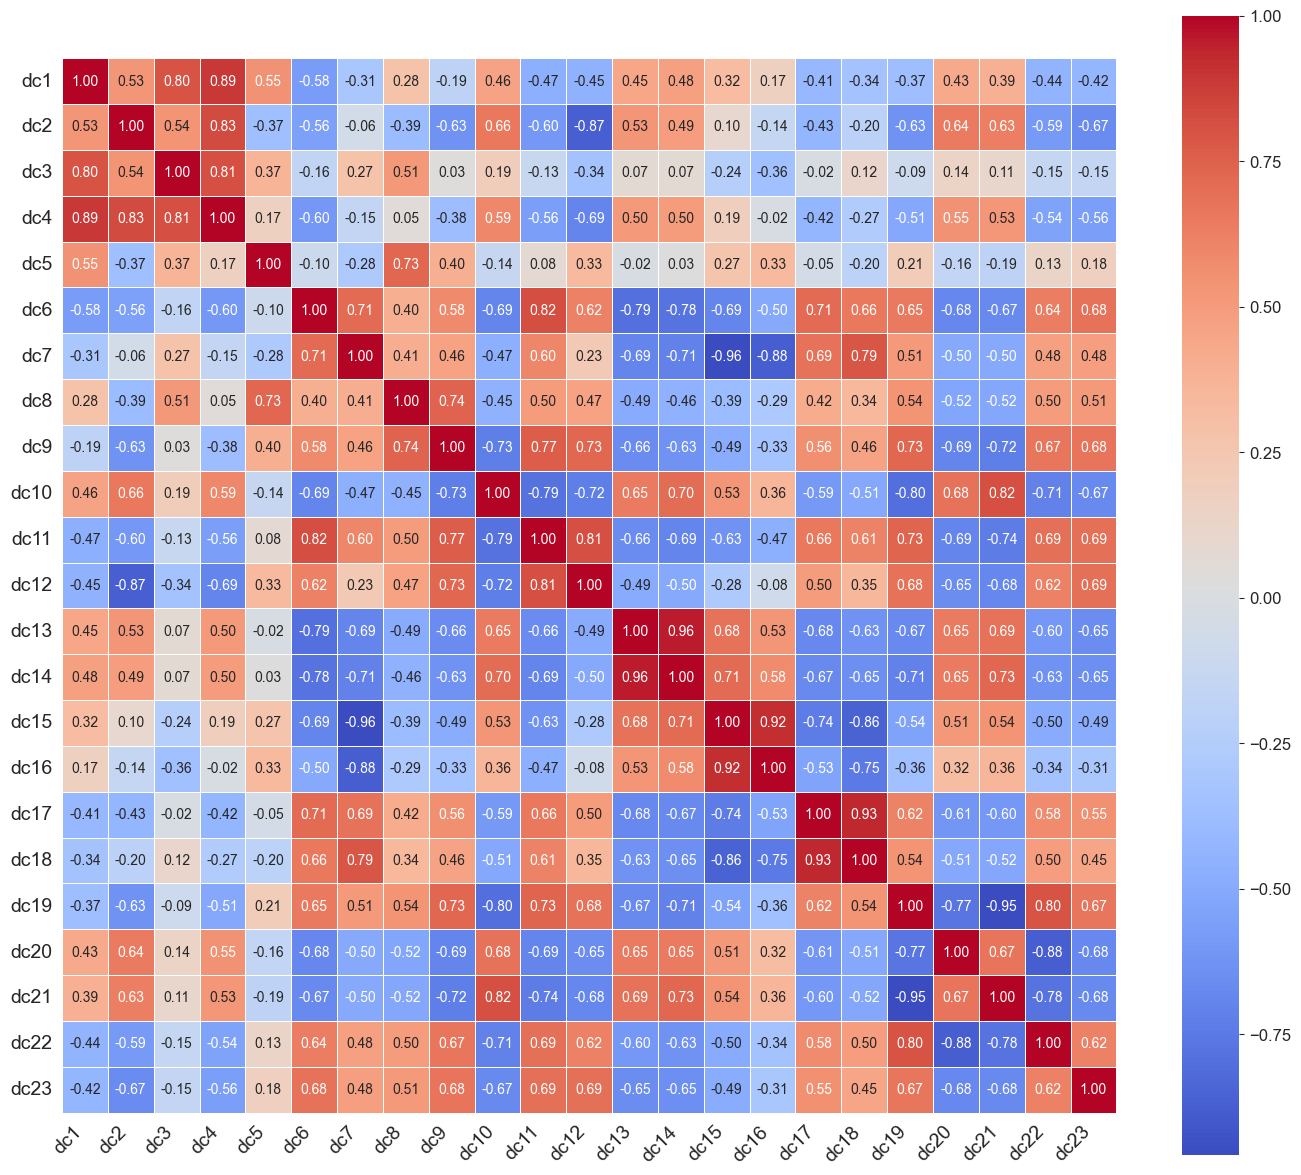

In [7]:
plt.figure(figsize=(14, 12))

ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10}   # hücre içi sayı fontu (istersen değiştir)
)

# ✅ X/Y eksen label fontlarını büyüt
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

# ✅ Colorbar tick fontunu büyüt (opsiyonel)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# ESKİ ANALİZLER

In [254]:
df_regression = pd.read_csv("df_regression.csv",  index_col=0)
df = df_regression.copy()

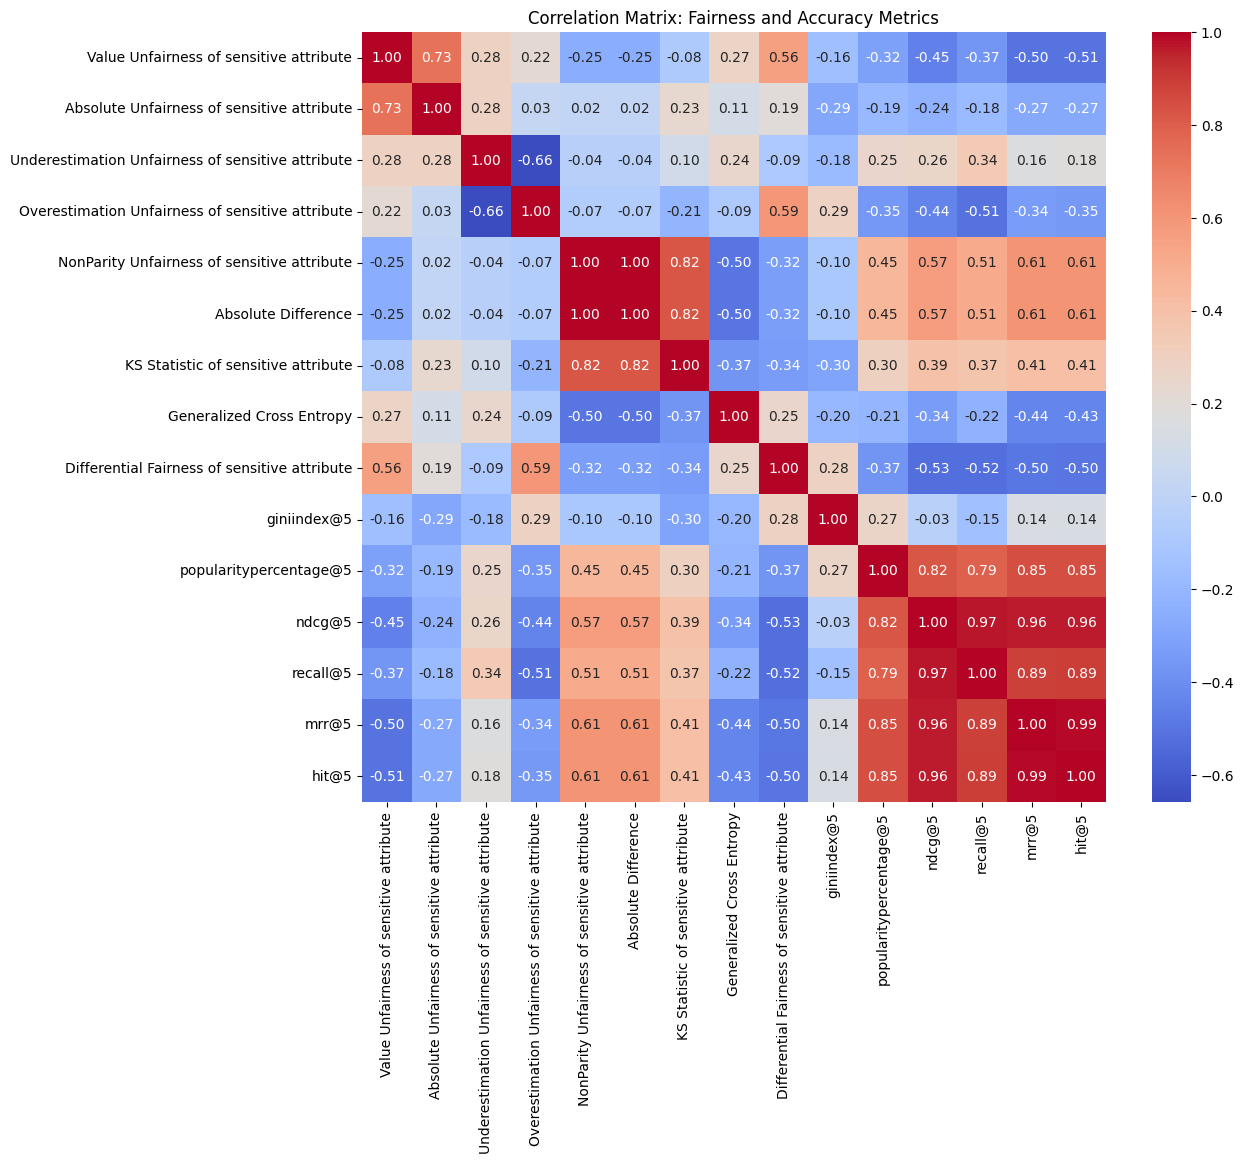

In [258]:

# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute',
    'giniindex@5',
       'popularitypercentage@5'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Select columns for fairness and accuracy metrics
selected_columns = fairness_measures + accuracy_metrics
selected_df = df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = selected_df.corr(method='spearman')

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix: Fairness and Accuracy Metrics")
plt.show()

In [255]:
df.columns

Index(['Model Name', 'Dataset', 'Subset ID', 'Is Filtered',
       'Sensitive Feature', 'ndcg@5', 'recall@5', 'mrr@5',
       'Differential Fairness of sensitive attribute', 'giniindex@5',
       'popularitypercentage@5', 'Value Unfairness of sensitive attribute',
       'Absolute Unfairness of sensitive attribute',
       'Underestimation Unfairness of sensitive attribute',
       'Overestimation Unfairness of sensitive attribute',
       'NonParity Unfairness of sensitive attribute', 'Absolute Difference',
       'KS Statistic of sensitive attribute', 'Generalized Cross Entropy',
       'hit@5', 'Number of Users', 'Number of Items', 'Number of Ratings',
       'Space Size', 'Shape', 'Density', 'Rating per User', 'Rating per Item',
       'Gini Item', 'Gini User', 'Average Popularity',
       'Standart Deviation of Popularity Bias', 'Skewness of Popularity Bias',
       'Kurtosis of Popularity Bias', 'Average Long Tail Items',
       'Standart Deviation of Long Tail Items', 'Skewness 

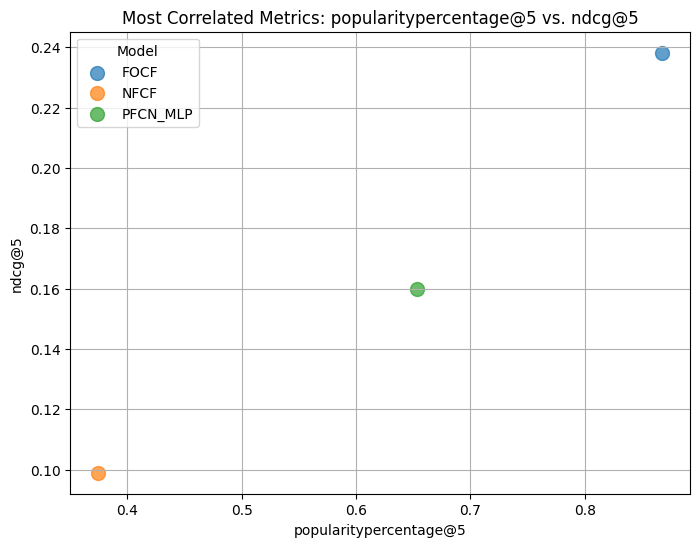

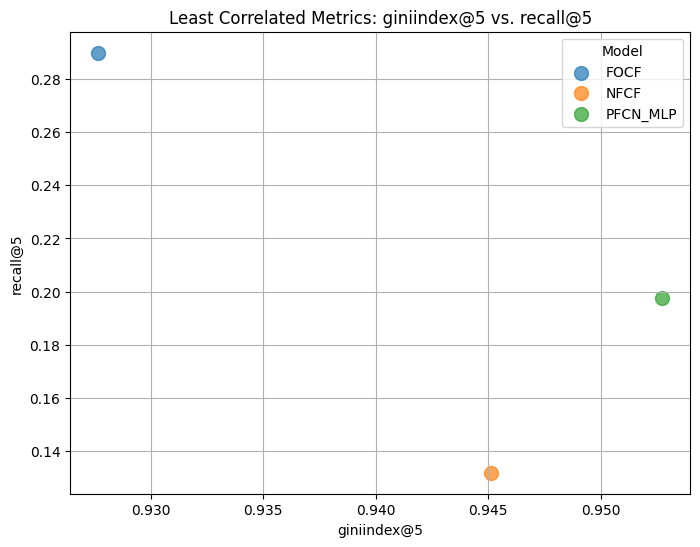

AttributeError: 'MultiIndex' object has no attribute '_data'

<Figure size 1000x800 with 0 Axes>

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute',
    'giniindex@5',
       'popularitypercentage@5'
    
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Compute correlation matrix
correlations = df[fairness_measures + accuracy_metrics].corr()

# Isolate fairness vs. accuracy correlations
fairness_vs_accuracy_corr = correlations.loc[fairness_measures, accuracy_metrics].abs()

# Identify the most and least correlated metric pairs
most_correlated = fairness_vs_accuracy_corr.stack().idxmax()
least_correlated = fairness_vs_accuracy_corr.stack().idxmin()

# Extract the metrics
most_corr_fairness, most_corr_accuracy = most_correlated
least_corr_fairness, least_corr_accuracy = least_correlated

# Calculate averages for each model (include all metrics this time)
model_averages = df.groupby("Model Name")[
    fairness_measures + accuracy_metrics
].mean()

# Calculate averages for each model-sensitive feature pair
model_sensitive_averages = df.groupby(["Model Name", "Sensitive Feature"])[
    fairness_measures + accuracy_metrics
].mean()

# Scatter plots with different colors for models
plt.figure(figsize=(8, 6))
for model_name, data in model_averages.iterrows():
    plt.scatter(
        data[most_corr_fairness],
        data[most_corr_accuracy],
        label=model_name,
        s=100,
        alpha=0.7
    )
plt.title(f"Most Correlated Metrics: {most_corr_fairness} vs. {most_corr_accuracy}")
plt.xlabel(most_corr_fairness)
plt.ylabel(most_corr_accuracy)
plt.legend(title="Model")
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, data in model_averages.iterrows():
    plt.scatter(
        data[least_corr_fairness],
        data[least_corr_accuracy],
        label=model_name,
        s=100,
        alpha=0.7
    )
plt.title(f"Least Correlated Metrics: {least_corr_fairness} vs. {least_corr_accuracy}")
plt.xlabel(least_corr_fairness)
plt.ylabel(least_corr_accuracy)
plt.legend(title="Model")
plt.grid()
plt.show()

# Scatter plot for model-sensitive feature pairs
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=most_corr_fairness,
    y=most_corr_accuracy,
    hue=model_sensitive_averages.index,
    style=model_sensitive_averages.index,
    s=100,
    data=model_sensitive_averages
)
plt.title(f"Most Correlated Metrics by Model-Sensitive Feature: {most_corr_fairness} vs. {most_corr_accuracy}")
plt.xlabel(most_corr_fairness)
plt.ylabel(most_corr_accuracy)
plt.legend(title="Model-Sensitive Feature")
plt.grid()
plt.show()

# Display the table of averaged metrics for each model
print("Averaged Metrics for Each Model:")
print(model_averages)

# Display the table of averaged metrics for model-sensitive feature pairs
print("Averaged Metrics for Model-Sensitive Feature Pairs:")
print(model_sensitive_averages)



### ChatGPT önerisi

In [120]:
import pandas as pd
import numpy as np

# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Calculate model-wise averages
model_averages = df.groupby("Model Name")[fairness_measures + accuracy_metrics].mean()

# Normalize fairness and accuracy metrics (Min-Max normalization)
normalized_data = (model_averages - model_averages.min()) / (model_averages.max() - model_averages.min())

# Separate normalized fairness and accuracy metrics
normalized_fairness = normalized_data[fairness_measures]
normalized_accuracy = normalized_data[accuracy_metrics]

# Calculate overall scores: fairness (lower is better) and accuracy (higher is better)
fairness_score = 1 - normalized_fairness.mean(axis=1)  # Invert fairness scores to align with "higher is better"
accuracy_score = normalized_accuracy.mean(axis=1)

# Combine scores into a single ranking
combined_score = (fairness_score + accuracy_score) / 2

# Add scores to the model averages
model_averages['Fairness Score'] = fairness_score
model_averages['Accuracy Score'] = accuracy_score
model_averages['Combined Score'] = combined_score

# Sort models by combined score
ranked_models = model_averages.sort_values(by='Combined Score', ascending=False)

# Display the ranked models
print("Ranked Models Based on Fairness and Accuracy:")
print(ranked_models)

# Save results to CSV (optional)
ranked_models.to_csv("ranked_models_fairness_accuracy.csv", index=True)


Ranked Models Based on Fairness and Accuracy:
            Value Unfairness of sensitive attribute  \
Model Name                                            
FOCF                                       0.328451   
PFCN_MLP                                   0.346224   
NFCF                                       0.377978   

            Absolute Unfairness of sensitive attribute  \
Model Name                                               
FOCF                                          0.278865   
PFCN_MLP                                      0.256189   
NFCF                                          0.297257   

            Underestimation Unfairness of sensitive attribute  \
Model Name                                                      
FOCF                                                 0.266579   
PFCN_MLP                                             0.113531   
NFCF                                                 0.103344   

            Overestimation Unfairness of sensitive attribute 

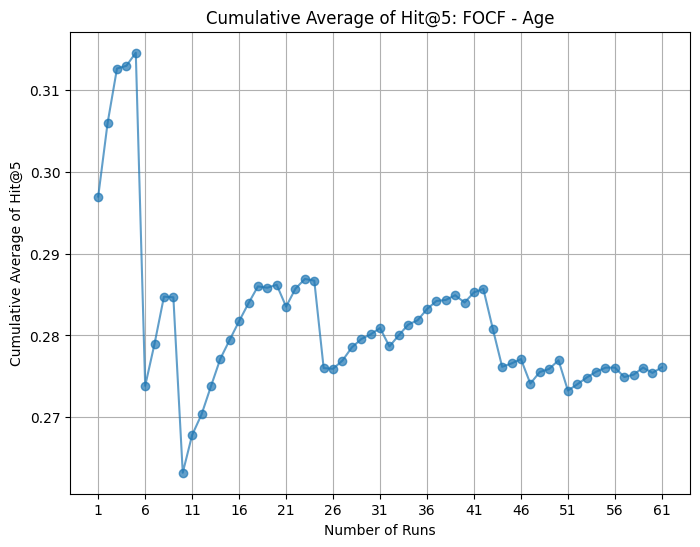

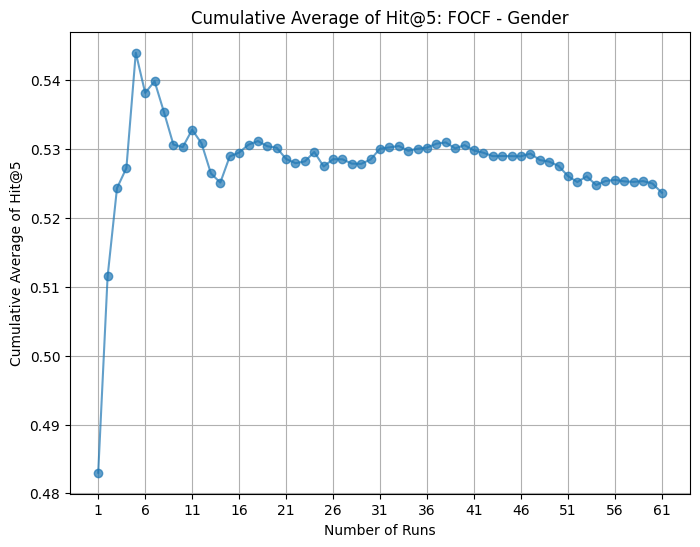

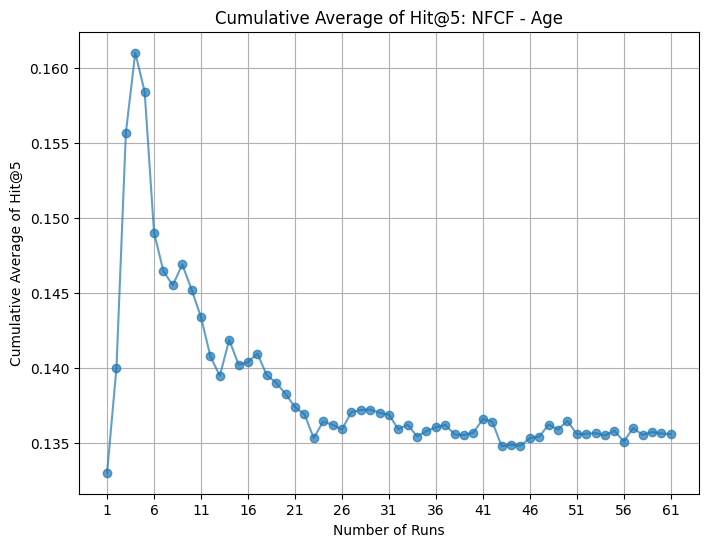

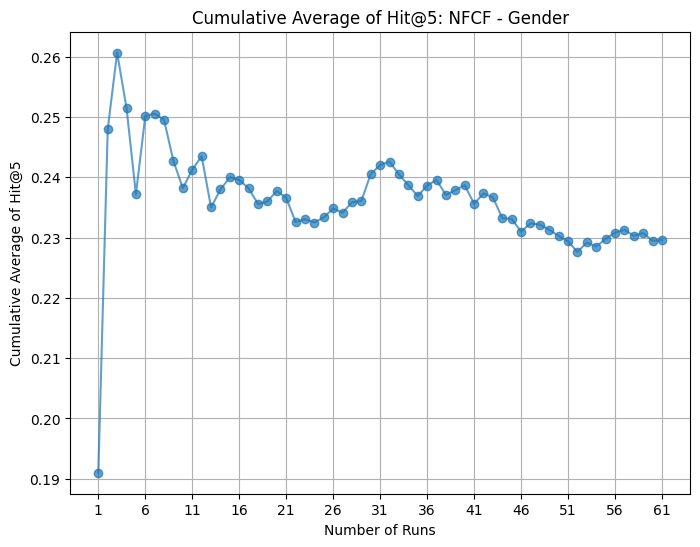

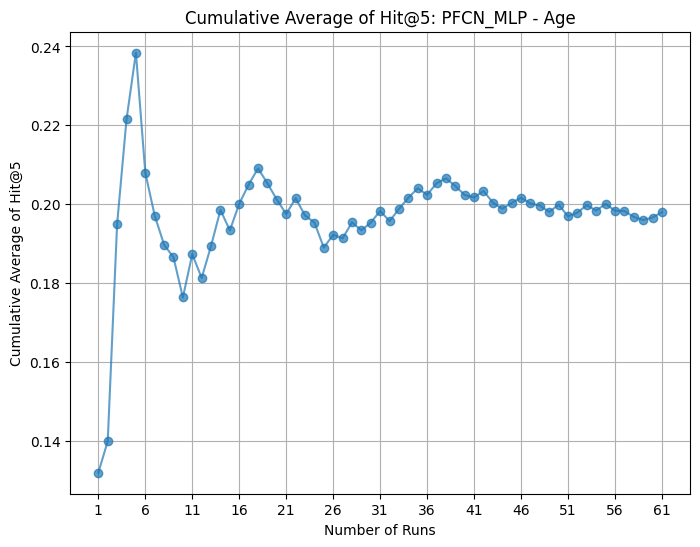

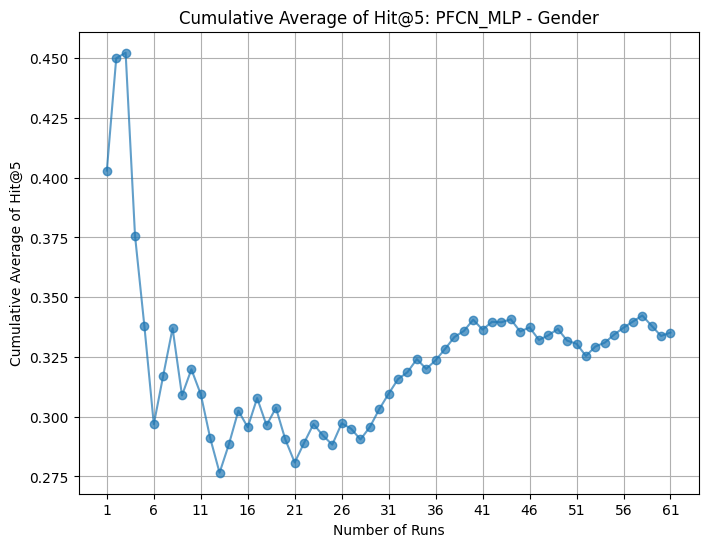

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset

# Group data by model name and sensitive feature
grouped_data = df.groupby(["Model Name", "Sensitive Feature"])

# Set the maximum number of ticks (e.g., 61)
max_ticks = 61

# Create cumulative average plots
for (model_name, sensitive_feature), group in grouped_data:
    # Sort and reset index for consistency
    group = group.sort_index().reset_index()

    # Ensure we have at least `max_ticks` rows
    if len(group) < max_ticks:
        continue

    # Calculate cumulative averages for `hit@5`
    cumulative_avg = group['hit@5'].iloc[:max_ticks].expanding().mean()

    # Plot the cumulative average
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, max_ticks + 1), cumulative_avg, marker='o', alpha=0.7)
    plt.title(f"Cumulative Average of Hit@5: {model_name} - {sensitive_feature}")
    plt.xlabel("Number of Runs")
    plt.ylabel("Cumulative Average of Hit@5")
    plt.xticks(range(1, max_ticks + 1, 5))  # Set ticks every 5 steps for clarity
    plt.grid()
    plt.show()


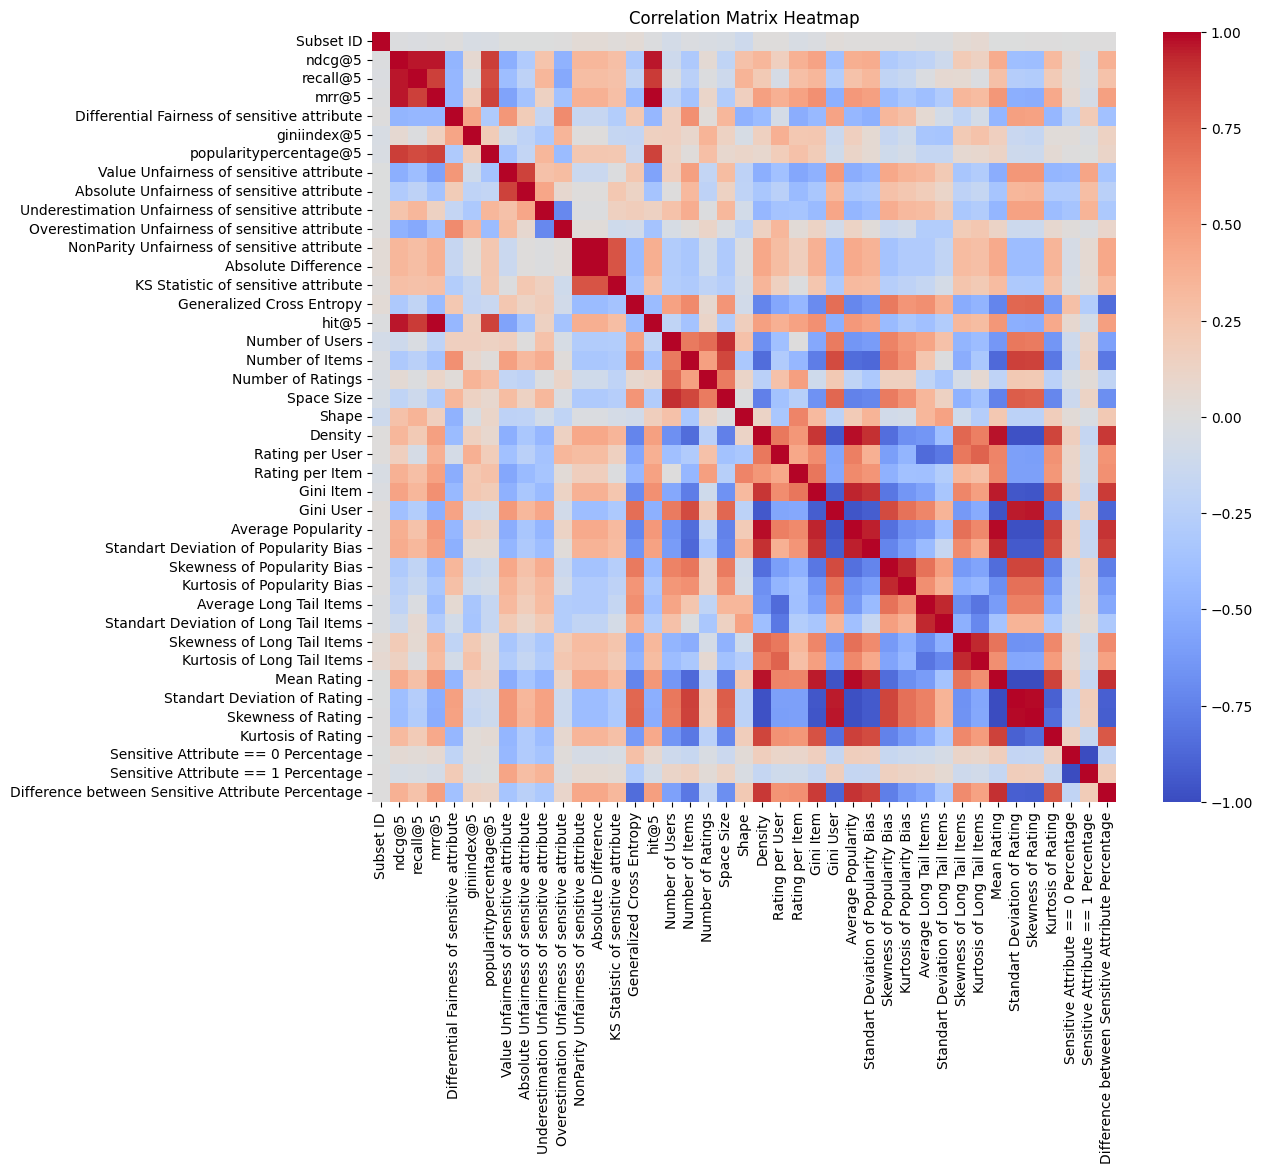

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for the heatmap
numeric_df = df.select_dtypes(include=["number"])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False,  cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

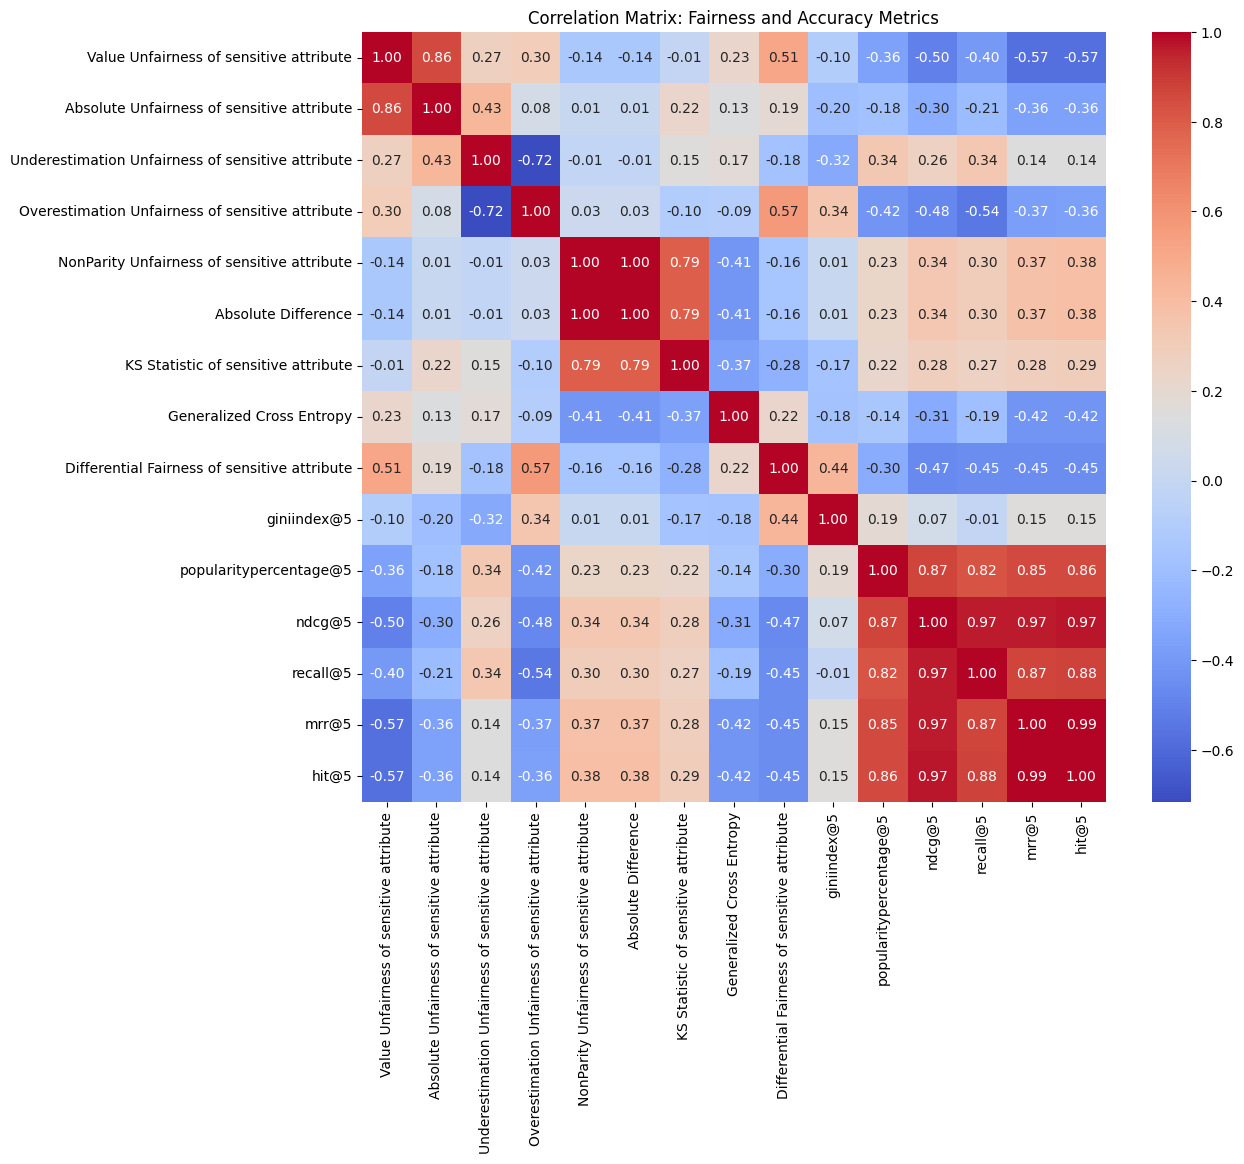

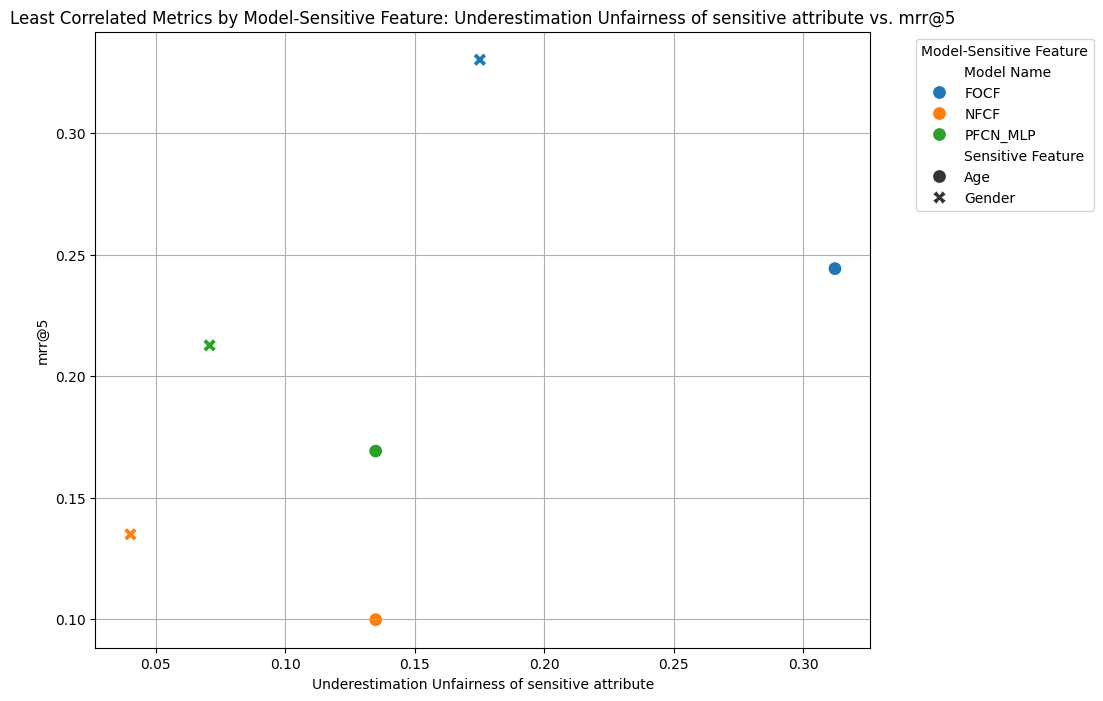

In [124]:
# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Compute correlation matrix and find least correlated metrics
correlations = df[fairness_measures + accuracy_metrics].corr()
fairness_vs_accuracy_corr = correlations.loc[fairness_measures, accuracy_metrics].abs()
least_correlated = fairness_vs_accuracy_corr.stack().idxmin()
least_corr_fairness, least_corr_accuracy = least_correlated

# Calculate averages for each model-sensitive feature pair
model_sensitive_averages = df.groupby(["Model Name", "Sensitive Feature"])[
    fairness_measures + accuracy_metrics
].mean()

# Scatter plot for least correlated metrics by model-sensitive feature
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=model_sensitive_averages[least_corr_fairness],
    y=model_sensitive_averages[least_corr_accuracy],
    hue=model_sensitive_averages.index.get_level_values(0),  # Model Name
    style=model_sensitive_averages.index.get_level_values(1),  # Sensitive Feature
    s=100
)
plt.title(f"Least Correlated Metrics by Model-Sensitive Feature: {least_corr_fairness} vs. {least_corr_accuracy}")
plt.xlabel(least_corr_fairness)
plt.ylabel(least_corr_accuracy)
plt.legend(title="Model-Sensitive Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

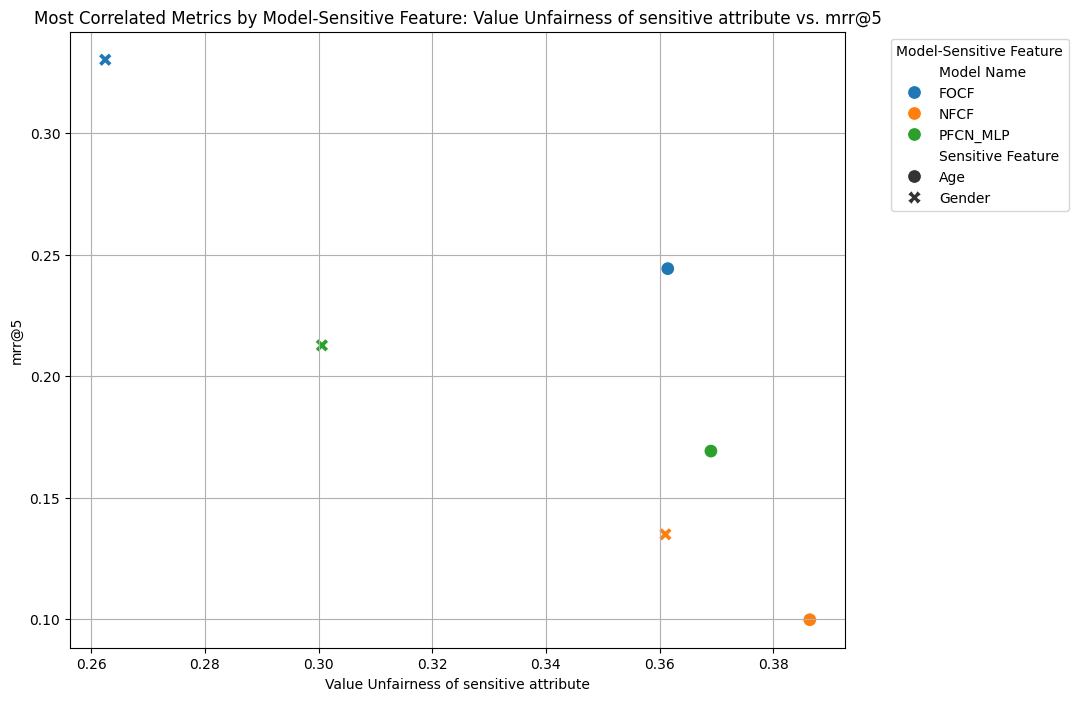

In [125]:

# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Compute correlation matrix and find most correlated metrics
correlations = df[fairness_measures + accuracy_metrics].corr()
fairness_vs_accuracy_corr = correlations.loc[fairness_measures, accuracy_metrics].abs()
most_correlated = fairness_vs_accuracy_corr.stack().idxmax()
most_corr_fairness, most_corr_accuracy = most_correlated

# Calculate averages for each model-sensitive feature pair
model_sensitive_averages = df.groupby(["Model Name", "Sensitive Feature"])[
    fairness_measures + accuracy_metrics
].mean()

# Scatter plot for most correlated metrics by model-sensitive feature
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=model_sensitive_averages[most_corr_fairness],
    y=model_sensitive_averages[most_corr_accuracy],
    hue=model_sensitive_averages.index.get_level_values(0),  # Model Name
    style=model_sensitive_averages.index.get_level_values(1),  # Sensitive Feature
    s=100
)
plt.title(f"Most Correlated Metrics by Model-Sensitive Feature: {most_corr_fairness} vs. {most_corr_accuracy}")
plt.xlabel(most_corr_fairness)
plt.ylabel(most_corr_accuracy)
plt.legend(title="Model-Sensitive Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

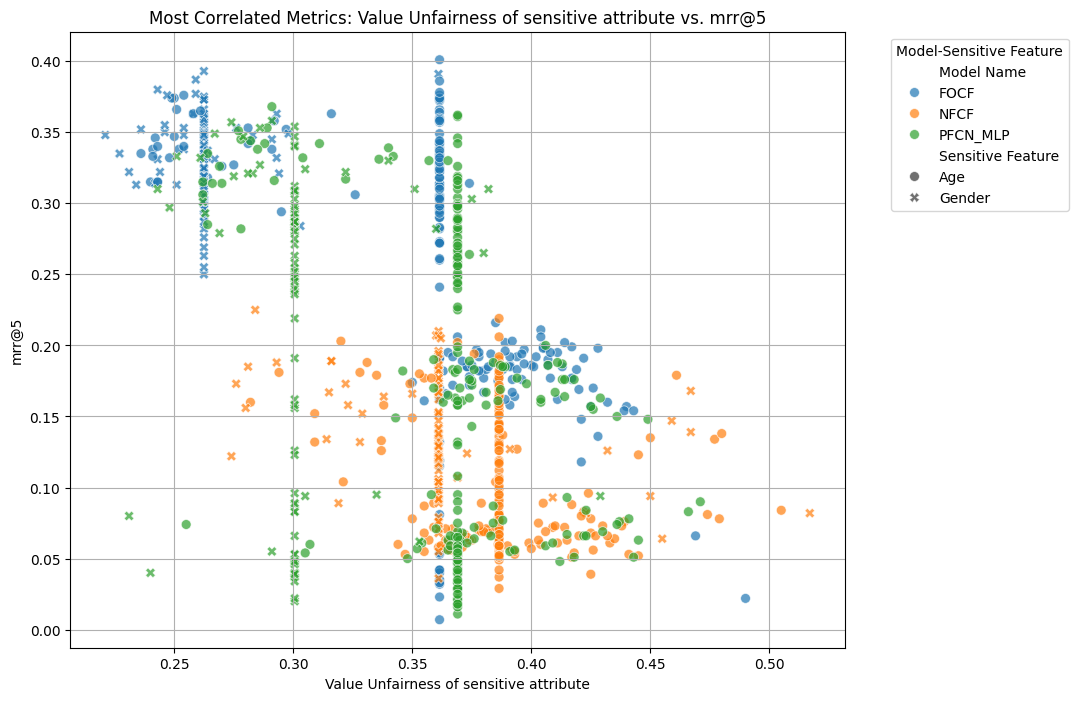

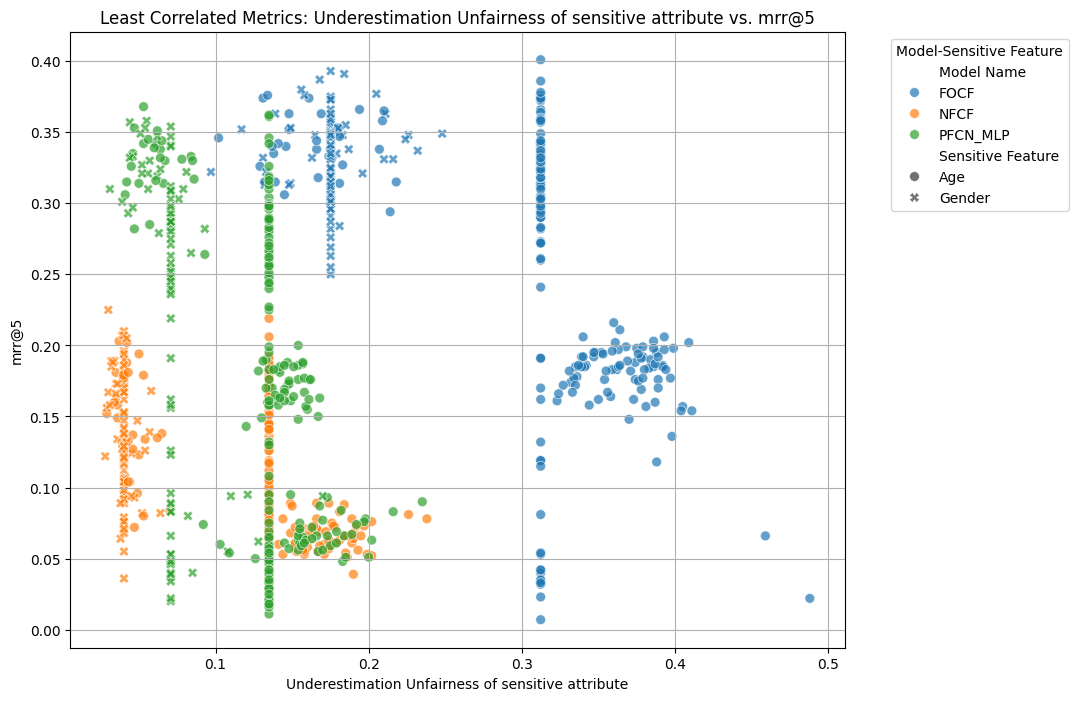

In [126]:
# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Compute correlation matrix
correlations = df[fairness_measures + accuracy_metrics].corr()
fairness_vs_accuracy_corr = correlations.loc[fairness_measures, accuracy_metrics].abs()

# Identify the most and least correlated metrics
most_correlated = fairness_vs_accuracy_corr.stack().idxmax()
least_correlated = fairness_vs_accuracy_corr.stack().idxmin()

most_corr_fairness, most_corr_accuracy = most_correlated
least_corr_fairness, least_corr_accuracy = least_correlated

# Scatter plot for most correlated metrics
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x=most_corr_fairness,
    y=most_corr_accuracy,
    hue="Model Name",
    style="Sensitive Feature",
    s=50,
    alpha=0.7
)
plt.title(f"Most Correlated Metrics: {most_corr_fairness} vs. {most_corr_accuracy}")
plt.xlabel(most_corr_fairness)
plt.ylabel(most_corr_accuracy)
plt.legend(title="Model-Sensitive Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

# Scatter plot for least correlated metrics
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x=least_corr_fairness,
    y=least_corr_accuracy,
    hue="Model Name",
    style="Sensitive Feature",
    s=50,
    alpha=0.7
)
plt.title(f"Least Correlated Metrics: {least_corr_fairness} vs. {least_corr_accuracy}")
plt.xlabel(least_corr_fairness)
plt.ylabel(least_corr_accuracy)
plt.legend(title="Model-Sensitive Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Calculate model-wise averages
model_averages = df.groupby("Model Name")[fairness_measures + accuracy_metrics].mean()

# Normalize fairness and accuracy metrics (Min-Max normalization)
normalized_data = (model_averages - model_averages.min()) / (model_averages.max() - model_averages.min())

# Separate normalized fairness and accuracy metrics
normalized_fairness = normalized_data[fairness_measures]
normalized_accuracy = normalized_data[accuracy_metrics]

# Calculate overall scores: fairness (lower is better) and accuracy (higher is better)
fairness_score = 1 - normalized_fairness.mean(axis=1)  # Invert fairness scores to align with "higher is better"
accuracy_score = normalized_accuracy.mean(axis=1)

# Combine scores into a single ranking
combined_score = (fairness_score + accuracy_score) / 2

# Add scores to the model averages
model_averages['Fairness Score'] = fairness_score
model_averages['Accuracy Score'] = accuracy_score
model_averages['Combined Score'] = combined_score

# Sort models by combined score
ranked_models = model_averages.sort_values(by='Combined Score', ascending=False)

# Limit to three decimal places
ranked_models = ranked_models.round(3)

# Save the ranked models to a CSV file
ranked_models.to_excel("ranked_models_fairness_accuracy.xlsx", index=True)


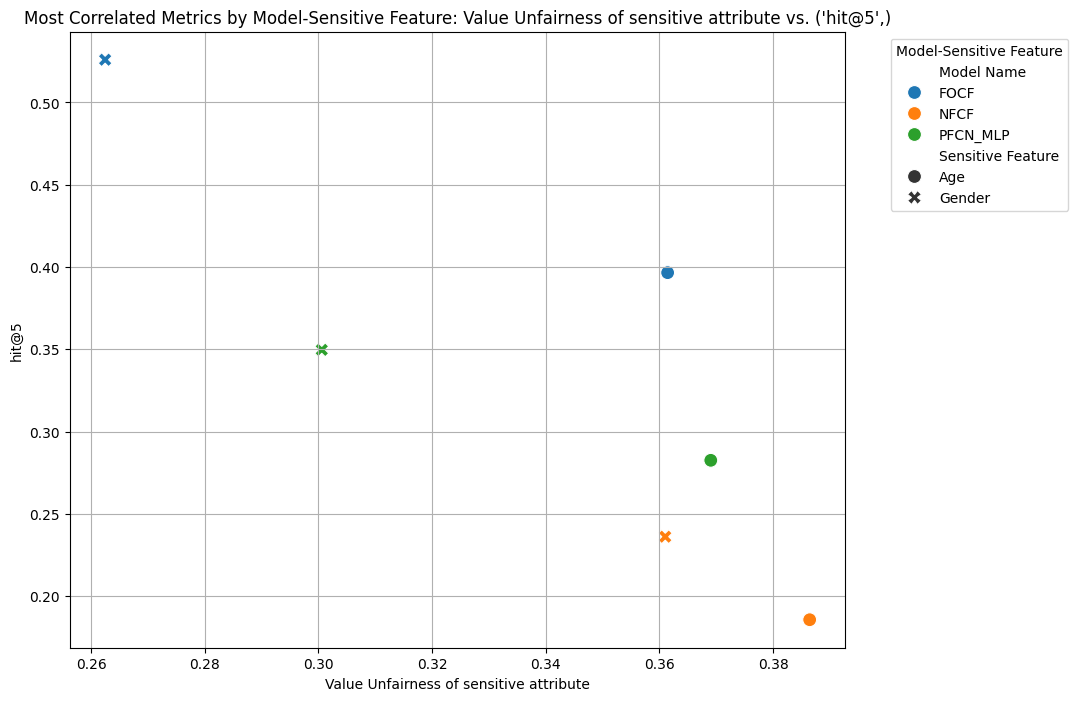

In [128]:

# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Compute correlation matrix and find most correlated metrics
correlations = df[fairness_measures + accuracy_metrics].corr()
fairness_vs_accuracy_corr = correlations.loc[fairness_measures, accuracy_metrics].abs()
most_correlated = fairness_vs_accuracy_corr.stack().idxmax()
most_corr_fairness, most_corr_accuracy = most_correlated

# Calculate averages for each model-sensitive feature pair
model_sensitive_averages = df.groupby(["Model Name", "Sensitive Feature"])[
    fairness_measures + accuracy_metrics
].mean()

# Scatter plot for most correlated metrics by model-sensitive feature
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=model_sensitive_averages['Value Unfairness of sensitive attribute'],
    y=model_sensitive_averages['hit@5'],
    hue=model_sensitive_averages.index.get_level_values(0),  # Model Name
    style=model_sensitive_averages.index.get_level_values(1),  # Sensitive Feature
    s=100
)
plt.title(f"Most Correlated Metrics by Model-Sensitive Feature: {'Value Unfairness of sensitive attribute'} vs. {'hit@5',}")
plt.xlabel('Value Unfairness of sensitive attribute')
plt.ylabel('hit@5')
plt.legend(title="Model-Sensitive Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

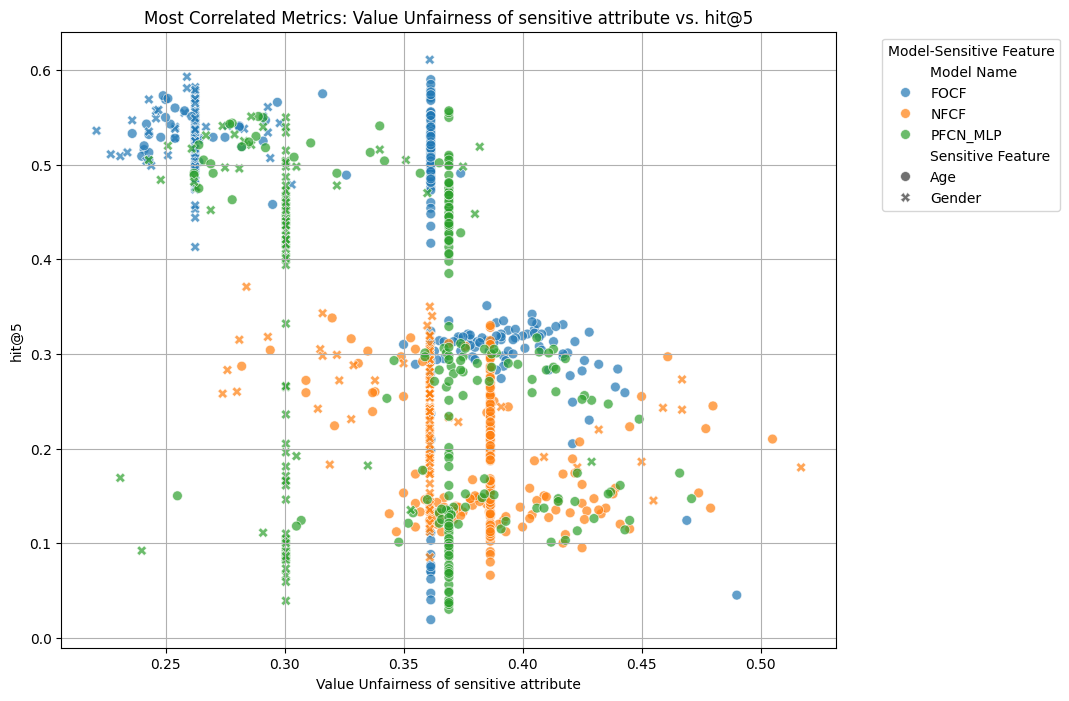

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define fairness and accuracy metrics
fairness_measures = [
    'Value Unfairness of sensitive attribute',
    'Absolute Unfairness of sensitive attribute',
    'Underestimation Unfairness of sensitive attribute',
    'Overestimation Unfairness of sensitive attribute',
    'NonParity Unfairness of sensitive attribute',
    'Absolute Difference',
    'KS Statistic of sensitive attribute',
    'Generalized Cross Entropy',
    'Differential Fairness of sensitive attribute'
]

accuracy_metrics = [
    'ndcg@5',
    'recall@5',
    'mrr@5',
    'hit@5',
]

# Compute correlation matrix
correlations = df[fairness_measures + accuracy_metrics].corr()
fairness_vs_accuracy_corr = correlations.loc[fairness_measures, accuracy_metrics].abs()

# Identify the most and least correlated metrics
most_correlated = fairness_vs_accuracy_corr.stack().idxmax()
least_correlated = fairness_vs_accuracy_corr.stack().idxmin()

most_corr_fairness = 'Value Unfairness of sensitive attribute'
most_corr_accuracy = 'hit@5'

# Scatter plot for most correlated metrics
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x=most_corr_fairness,
    y=most_corr_accuracy,
    hue="Model Name",
    style="Sensitive Feature",
    s=50,
    alpha=0.7
)
plt.title(f"Most Correlated Metrics: {most_corr_fairness} vs. {most_corr_accuracy}")
plt.xlabel(most_corr_fairness)
plt.ylabel(most_corr_accuracy)
plt.legend(title="Model-Sensitive Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

